# 🎬 영화 데이터 분석

씨네21의 영화 상세 정보 스크래핑 진행 및 Kobis API를 호출한 데이터를 활용하여 데이터 분석 진행

**데이터 집계 기간**<br>
    * 스크래핑 데이터 : 2026년 08월 07일 ~ 2026년 08월 14일 (`movie_master`, `review`)<br>
    * API 데이터 : 2025년 8월 15일 ~ 2026년 8월 14일 (`movie_info`)

**데이터**
* movie_master.csv
* movie_info.csv
* review.csv

**📌 분석 방향**
1. 집계 기간(20260807 ~ 20260814) Top 10 영화 데이터 EDA
2. Kobis의 1년치 데이터로 시계열 분석 진행
3. 집계 기간 Top 10 영화 데이터 리뷰 텍스트 분석 진행

# 1. 데이터 준비하기 및 기본 세팅

In [1]:
# 라이브러리 호출
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import plotly.express as px
from pathlib import Path

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
# 데이터 호출
movie_df = pd.read_csv('../data/pre_processed/movie_info.csv')
review_df = pd.read_csv('../data/pre_processed/review.csv')
master_df = pd.read_csv('../data/pre_processed/movie_master.csv')

In [3]:
# 한글 폰트 지정 및 마이너스 깨짐 방지 - 맥
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

In [4]:
def draw_lineChart (df, y_val, title, ylabel, is_rank=False):

    autorange = "reversed" if is_rank else True
    dtick = 1 if is_rank else None
    
    fig = px.line(
        df, 
        x='b_date', 
        y=y_val, 
        color='movieNm',
        markers=True,
        title=title,
        hover_data=['movieNm', 'b_date', y_val]
    )
    
    fig.update_layout(
        yaxis=dict(
            autorange=autorange,
            dtick=dtick,
            title=f'{ylabel} ({y_val})'
        ),
        xaxis=dict(
            title='날짜 (Date)',
            tickangle=-45
        ),
        # --- [수정 구간] 범례 위치 및 여백 설정 ---
        legend=dict(
            orientation="h",        # 범례를 가로로 배치
            yanchor="top",
            y=-0.25,                # x축 아래로 배치 (값으로 위치 조정 가능)
            xanchor="center",
            x=0.5,                  # 중앙 정렬
            title_text=''           # 범례 제목 제거로 공간 확보
        ),
        margin=dict(b=150),          # 하단 여백을 늘려 범례 잘림 방지
        # ----------------------------------------
        hovermode="x unified",
        template='plotly_white',
        width=1000,
        height=650                  # 범례 공간 확보를 위해 높이 약간 확대
    )

    fig.show()

# 2. 데이터 확인 및 1차 전처리

## 2-1. master_df 확인

In [5]:
master_df

,title,score,id,genre,grade,time,director,expert_score,nation,movieCd
0,눈동자,5.00,63186.0,스릴러,15세이상관람가,105분,염지호,5.00,한국,20242402
1,다윗,5.00,63108.0,애니메이션,전체관람가,109분,필커닝햄,5.00,미국,20262902
2,명탐정 코난: 하이웨이의 타천사,6.00,63245.0,애니메이션,12세이상관람가,109분,하스이타카히로,6.00,일본,20264635
3,모아나,5.67,62818.0,"어드벤처,액션",전체관람가,115분,토마스케일,5.67,미국,20259946
4,미니언즈 & 몬스터즈,6.50,63032.0,애니메이션,전체관람가,89분,피에르코팽,6.50,미국,20261784
5,사랑의 하츄핑: 고래보석의 전설,7.00,63075.0,애니메이션,전체관람가,105분,김수훈,7.00,한국,20262381
6,스파이더맨: 브랜드 뉴 데이,7.33,63091.0,"판타지,어드벤처,액션",12세이상관람가,144분,데스틴크리튼,7.33,미국,20262770
7,어떻게 해야 했을까?,6.50,63282.0,다큐멘터리,12세이상관람가,101분,후지노토모아키,6.50,일본,20264148
8,오디세이,7.55,62585.0,"액션,모험,드라마",15세이상관람가,172분,크리스토퍼놀란,7.55,미국,20250654
9,오케이 마담2,5.00,63240.0,"액션,코미디",15세이상관람가,108분,이철하,5.00,한국,20255484


In [6]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         12 non-null     object 
 1   score         12 non-null     float64
 2   id            12 non-null     float64
 3   genre         12 non-null     object 
 4   grade         12 non-null     object 
 5   time          12 non-null     object 
 6   director      12 non-null     object 
 7   expert_score  12 non-null     float64
 8   nation        12 non-null     object 
 9   movieCd       12 non-null     int64  
dtypes: float64(3), int64(1), object(6)
memory usage: 1.1+ KB


* `id` 컬럼
    * .0 삭제
    * 문자열 변환 필요
* `time` 컬럼
    * 단위 "분" 삭제
    * 숫자형 변환 필요
* `score`와 `expert_score` 동일 현상 확인
  * `score`는 영화 랭킹 리스트에 표현되는 별점 점수 / `expert_score`는 전문가의 별점 점수
  * 두 데이터가 같은 데이터를 표현하고 있어서, 하나의 컬럼 삭제 (`score` 삭제)
  * 관객의 별점을 수동으로 추가 확보 진행 (`audi_score`)

In [7]:
# id 컬럼 
master_df['id'] = master_df['id'].astype('int').astype('str')

In [8]:
# time 컬럼
master_df['time'] = master_df['time'].str.extract(r"(\d+)").astype(int)

In [9]:
# score 삭제
master_df = master_df.drop(['score'], axis=1)

# 관객 평점 추가
# 관객 점수는 8월 15일 16시 40분 씨네 21의 자료를 기준으로 함
score_dict = {
    '눈동자': 5.25,
    '다윗': 7.00,
    '명탐정 코난: 하이웨이의 타천사': 0.00, # 해당 영화는 현재 씨네 21에 자료가 존재하지 않음.
    '모아나' : 6.33,
    '미니언즈 & 몬스터즈' : 7.00,
    '사랑의 하츄핑: 고래보석의 전설' : 10.00,
    '스파이더맨: 브랜드 뉴 데이' : 7.31,
    '어떻게 해야 했을까?' : 5.00,
    '오디세이' : 8.11,
    '오케이 마담2' : 5.50,
    '토이 스토리 5' : 9.40,
    '호프' : 5.89
}

master_df['audi_score'] = master_df['title'].map(score_dict)

In [10]:
master_df

,title,id,genre,grade,time,director,expert_score,nation,movieCd,audi_score
0,눈동자,63186,스릴러,15세이상관람가,105,염지호,5.00,한국,20242402,5.25
1,다윗,63108,애니메이션,전체관람가,109,필커닝햄,5.00,미국,20262902,7.00
2,명탐정 코난: 하이웨이의 타천사,63245,애니메이션,12세이상관람가,109,하스이타카히로,6.00,일본,20264635,0.00
3,모아나,62818,"어드벤처,액션",전체관람가,115,토마스케일,5.67,미국,20259946,6.33
4,미니언즈 & 몬스터즈,63032,애니메이션,전체관람가,89,피에르코팽,6.50,미국,20261784,7.00
5,사랑의 하츄핑: 고래보석의 전설,63075,애니메이션,전체관람가,105,김수훈,7.00,한국,20262381,10.00
6,스파이더맨: 브랜드 뉴 데이,63091,"판타지,어드벤처,액션",12세이상관람가,144,데스틴크리튼,7.33,미국,20262770,7.31
7,어떻게 해야 했을까?,63282,다큐멘터리,12세이상관람가,101,후지노토모아키,6.50,일본,20264148,5.00
8,오디세이,62585,"액션,모험,드라마",15세이상관람가,172,크리스토퍼놀란,7.55,미국,20250654,8.11
9,오케이 마담2,63240,"액션,코미디",15세이상관람가,108,이철하,5.00,한국,20255484,5.50


In [11]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         12 non-null     object 
 1   id            12 non-null     object 
 2   genre         12 non-null     object 
 3   grade         12 non-null     object 
 4   time          12 non-null     int64  
 5   director      12 non-null     object 
 6   expert_score  12 non-null     float64
 7   nation        12 non-null     object 
 8   movieCd       12 non-null     int64  
 9   audi_score    12 non-null     float64
dtypes: float64(2), int64(2), object(6)
memory usage: 1.1+ KB


In [12]:
# 결측값 확인
print(f'결측값 : {master_df.isna().sum().sum()}')
# 중복값 확인
print(f'중복값 : {master_df.duplicated().sum()}')

결측값 : 0
중복값 : 0


## 2-2. movie_df 확인

In [13]:
movie_df.head(5)

,rank,rankInten,rankOldAndNew,movieCd,movieNm,openDt,salesAmt,salesShare,salesInten,salesChange,salesAcc,audiCnt,audiInten,audiChange,audiAcc,scrnCnt,showCnt,b_date,c_date
0,1,0,OLD,20241941,좀비딸,2025-07-30,2835148970,41.6,1802045840,174.4,38201765980,290709,179756,162.0,4046131,1438,6343,2025-08-15,2026-08-15 16:20:45
1,2,0,OLD,20254501,F1 더 무비,2025-06-25,1598074170,23.4,966333630,153.0,42788953890,140886,84004,147.7,3971606,937,2792,2025-08-15,2026-08-15 16:20:45
2,3,0,OLD,20210546,악마가 이사왔다,2025-08-13,720667880,10.6,365484310,102.9,1567588050,73914,34804,89.0,166307,839,3181,2025-08-15,2026-08-15 16:20:45
3,4,0,OLD,20256701,긴키 지방의 어느 장소에 대하여,2025-08-13,251920180,3.7,111967060,80.0,530160100,24374,10015,69.7,52879,411,613,2025-08-15,2026-08-15 16:20:45
4,5,1,OLD,20254275,킹 오브 킹스,2025-07-16,210550250,3.1,146233700,227.4,11395045306,21818,14748,208.6,1206408,526,707,2025-08-15,2026-08-15 16:20:45


In [14]:
movie_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   rank           3650 non-null   int64  
 1   rankInten      3650 non-null   int64  
 2   rankOldAndNew  3650 non-null   object 
 3   movieCd        3650 non-null   int64  
 4   movieNm        3650 non-null   object 
 5   openDt         3650 non-null   object 
 6   salesAmt       3650 non-null   int64  
 7   salesShare     3650 non-null   float64
 8   salesInten     3650 non-null   int64  
 9   salesChange    3650 non-null   float64
 10  salesAcc       3650 non-null   int64  
 11  audiCnt        3650 non-null   int64  
 12  audiInten      3650 non-null   int64  
 13  audiChange     3650 non-null   float64
 14  audiAcc        3650 non-null   int64  
 15  scrnCnt        3650 non-null   int64  
 16  showCnt        3650 non-null   int64  
 17  b_date         3650 non-null   object 
 18  c_date  

* `openDt`, `b_date`, `c_date` 컬럼
    * 날짜형 변경

In [15]:
# openDt 날짜형 변환
movie_df['openDt'] = pd.to_datetime(movie_df['openDt'], errors='coerce')
# b_date 날짜형 변환
movie_df['b_date'] = pd.to_datetime(movie_df['b_date'], errors='coerce')
# c_date 날짜형 변환
movie_df['c_date'] = pd.to_datetime(movie_df['c_date'], errors='coerce')

In [16]:
movie_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   rank           3650 non-null   int64         
 1   rankInten      3650 non-null   int64         
 2   rankOldAndNew  3650 non-null   object        
 3   movieCd        3650 non-null   int64         
 4   movieNm        3650 non-null   object        
 5   openDt         3642 non-null   datetime64[ns]
 6   salesAmt       3650 non-null   int64         
 7   salesShare     3650 non-null   float64       
 8   salesInten     3650 non-null   int64         
 9   salesChange    3650 non-null   float64       
 10  salesAcc       3650 non-null   int64         
 11  audiCnt        3650 non-null   int64         
 12  audiInten      3650 non-null   int64         
 13  audiChange     3650 non-null   float64       
 14  audiAcc        3650 non-null   int64         
 15  scrnCnt        3650 n

In [17]:
# 결측값 확인
print(f'결측값 : {movie_df.isna().sum().sum()}')
# 중복값 확인
print(f'중복값 : {movie_df.duplicated().sum()}')

결측값 : 8
중복값 : 0


In [18]:
# 결측값 확인
movie_df[movie_df["openDt"].isna()]

,rank,rankInten,rankOldAndNew,movieCd,movieNm,openDt,salesAmt,salesShare,salesInten,salesChange,salesAcc,audiCnt,audiInten,audiChange,audiAcc,scrnCnt,showCnt,b_date,c_date
49,10,1,OLD,20256522,백! 스테이지,NaT,11430000,0.8,3447000,43.2,19413000,2286,691,43.3,3881,25,42,2025-08-19,2026-08-15 16:20:42
658,9,0,NEW,20258628,이찬원 정규 2집 ‘찬란’ 청음회,NaT,23568000,0.8,23568000,100.0,23568000,5892,5892,100.0,5892,40,40,2025-10-19,2026-08-15 16:17:06
2998,9,0,NEW,20264226,쏜애플 '나의 세기' 익스텐디드 플레이 필름,NaT,24000000,1.3,24000000,100.0,24000000,2000,2000,100.0,2000,29,60,2026-06-10,2026-08-15 15:58:31
3036,7,0,NEW,20264331,디어 마이 히어로,NaT,27500000,0.8,27500000,100.0,27500000,5500,5500,100.0,5500,120,328,2026-06-14,2026-08-15 15:58:28
3048,9,-2,OLD,20264331,디어 마이 히어로,NaT,8790000,0.9,-18710000,-68.0,36290000,1758,-3742,-68.0,7258,110,279,2026-06-15,2026-08-15 15:58:28
3057,8,1,OLD,20264331,디어 마이 히어로,NaT,7305000,0.7,-1485000,-16.9,43595000,1461,-297,-16.9,8719,113,279,2026-06-16,2026-08-15 15:58:27
3109,10,3,OLD,20264331,디어 마이 히어로,NaT,12375000,0.3,4860000,64.7,78610000,2475,972,64.7,15722,153,185,2026-06-21,2026-08-15 15:58:08
3349,10,0,NEW,20261421,나무의 노래,NaT,9297000,0.2,9297000,100.0,36505000,1033,1033,100.0,4185,6,6,2026-07-15,2026-08-15 15:57:51


씨네21에서 찾은 open_date 결측치인 영화 url 목록

- 백! 스테이지: https://cine21.com/movie/info/?movie_id=62482
    - 개봉일: 2025-08-18
- 이찬원 정규 2집 ‘찬란’ 청음회: https://cine21.com/movie/info/?movie_id=62689
    - 개봉일: 2025-10-19
- 쏜애플 '나의 세기' 익스텐디드 플레이 필름: 씨네21엔 기록없음. 네이버 검색 진행
    - 링크: https://search.naver.com/search.naver?sm=tab_hty.top&where=nexearch&ssc=tab.nx.all&query=%EC%8F%9C%EC%95%A0%ED%94%8C+%27%EB%82%98%EC%9D%98+%EC%84%B8%EA%B8%B0%27+%EC%9D%B5%EC%8A%A4%ED%85%90%EB%94%94%EB%93%9C+%ED%94%8C%EB%A0%88%EC%9D%B4+%ED%95%84%EB%A6%84&oquery=%EC%8F%9C%EC%95%A0%ED%94%8C+%27%EB%82%98%EC%9D%98+%EC%84%B8%EA%B8%B0%27&tqi=josjGdp0jprQymYmgeG-072031&ackey=b55zsfjp
    - 개봉일: 2026년 6월 10일
- 디어 마이 히어로: 씨네21엔 기록없음. 네이버 검색 진행
    - 링크: https://search.naver.com/search.naver?sm=tab_hty.top&where=nexearch&ssc=tab.nx.all&query=%EB%94%94%EC%96%B4+%EB%A7%88%EC%9D%B4+%ED%9E%88%EC%96%B4%EB%A1%9C&oquery=%EC%8F%9C%EC%95%A0%ED%94%8C+%27%EB%82%98%EC%9D%98+%EC%84%B8%EA%B8%B0%27+%EC%9D%B5%EC%8A%A4%ED%85%90%EB%94%94%EB%93%9C+%ED%94%8C%EB%A0%88%EC%9D%B4+%ED%95%84%EB%A6%84&tqi=joskKdqosC8ssTNfMmK-256642&ackey=uy0o698h
    - 개봉일: 2026.06.14

- 나무의 노래: 씨네21에 기록 없으며 뉴스 기사등으로 확인할 때, 올해 9월 개봉 예정작
    - 관련 뉴스 링크: https://news.knn.co.kr/news/article_sns/1549


=> 확인 결과,

- 나무의 노래는 정말 open_date가 없고, 미래 개봉작이 미리 등록된 현황이며 1건이기에 전체 데이터 흐름에 크게 영향을 미치지 않을 것으로 판단. 단, 시계열 분석에서는 필요한 데이터이므로 open_date가 필요한 분석에서만 제외하고 판단하기로 함

In [19]:
# open_date 개봉일 값으로 지정해 넣어주기
movie_df.loc[movie_df['movieNm'] == '백! 스테이지', 'openDt'] = pd.to_datetime('2025-08-18')
movie_df.loc[movie_df['movieNm'] == '이찬원 정규 2집 ‘찬란’ 청음회', 'openDt'] = pd.to_datetime('2025-10-19')
movie_df.loc[movie_df['movieNm'] == "쏜애플 '나의 세기' 익스텐디드 플레이 필름", 'openDt'] = pd.to_datetime('2026-06-10')
movie_df.loc[movie_df['movieNm'] == '디어 마이 히어로', 'openDt'] = pd.to_datetime('2026-06-14')

In [20]:
# 결측값 확인
print(f'결측값 : {movie_df.isna().sum().sum()}')

결측값 : 1


## 2-3. review_df 확인

In [21]:
review_df.head(5)

,id,reviewer_name,score,review
0,63091,송경원,7,하이틴의 겉옷을 벗고 근본으로 돌아간 성장
1,63091,정재현,7,큰 힘과 큰 책임이 서로를 따르지 못할 때에도 당신이 히어로라면
2,63091,이자연,7,도파민형 영웅이 가득한 세상에서 ‘선함’을 지켜낸 ‘강한’ 히어로
3,63091,이우빈,7,역시 스파이더맨은 고통받을수록 강하고 재밌다
4,63091,박평식,7,캐릭터도 캐스트도 발맞춰 잘 자랐구나


In [22]:
review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             51 non-null     int64 
 1   reviewer_name  51 non-null     object
 2   score          51 non-null     int64 
 3   review         51 non-null     object
dtypes: int64(2), object(2)
memory usage: 1.7+ KB


In [23]:
# 결측값 확인
print(f'결측값 : {review_df.isna().sum().sum()}')
# 중복값 확인
print(f'중복값 : {review_df.duplicated().sum()}')

결측값 : 0
중복값 : 0


# 3. 분석용 테이블 (merge_df) 만들기
* `movie_df`, `master_df` - inner join

In [24]:
merged_df = pd.merge(
    movie_df,              
    master_df,             
    on='movieCd',
    how='inner'
)

In [25]:
# None으로 설정하면 컬럼 수 제한 없이 전부 출력
pd.set_option('display.max_columns', None)

# 확인
merged_df.head()

,rank,rankInten,rankOldAndNew,movieCd,movieNm,openDt,salesAmt,salesShare,salesInten,salesChange,salesAcc,audiCnt,audiInten,audiChange,audiAcc,scrnCnt,showCnt,b_date,c_date,title,id,genre,grade,time,director,expert_score,nation,audi_score
0,10,0,NEW,20259781,토이 스토리 5,2026-06-17,23817000,1.7,23817000,100.0,23817000,1537,1537,100.0,1537,2,3,2026-06-11,2026-08-15 15:58:31,토이 스토리 5,62799,애니메이션,전체관람가,101,앤드류스탠튼,6.83,미국,9.40
1,6,0,NEW,20242402,눈동자,2026-06-24,28179000,2.8,28179000,100.0,30186000,2879,2879,100.0,3102,13,13,2026-06-15,2026-08-15 15:58:28,눈동자,63186,스릴러,15세이상관람가,105,염지호,5.00,한국,5.25
2,1,0,NEW,20259781,토이 스토리 5,2026-06-17,997525790,50.1,997525790,100.0,1021342790,94694,94694,100.0,96231,1538,6104,2026-06-17,2026-08-15 15:58:26,토이 스토리 5,62799,애니메이션,전체관람가,101,앤드류스탠튼,6.83,미국,9.40
3,1,0,OLD,20259781,토이 스토리 5,2026-06-17,663139770,40.4,-334386020,-33.5,1684482560,63122,-31572,-33.3,159353,1495,5801,2026-06-18,2026-08-15 15:58:15,토이 스토리 5,62799,애니메이션,전체관람가,101,앤드류스탠튼,6.83,미국,9.40
4,1,0,OLD,20259781,토이 스토리 5,2026-06-17,973355600,45.9,310215830,46.8,2657838160,90267,27145,43.0,249620,1564,6209,2026-06-19,2026-08-15 15:58:15,토이 스토리 5,62799,애니메이션,전체관람가,101,앤드류스탠튼,6.83,미국,9.40


* 필요 컬럼 정의
  * `rank`, `movieCd`, `movieNm`, `openDt`, `salesAmt`, `salesAcc`, `audiCnt`, `audiAcc`, `scrnCnt`, `showCnt`, `b_date`, `id`, `genre`, `grade`, `time`, `director`, `expert_score`, `nation`, `audi_score`

In [26]:
# 정의된 필수 컬럼 리스트
required_cols = [
    'rank',
    'movieCd',
    'movieNm',
    'openDt',
    'salesAmt',
    'salesAcc',
    'audiCnt',
    'audiAcc',
    'scrnCnt',
    'showCnt',
    'b_date',
    'id',
    'genre',
    'grade',
    'time',
    'director',
    'expert_score',
    'nation',
    'audi_score',
]

merged_df = merged_df[required_cols]

In [27]:
merged_df.head()

,rank,movieCd,movieNm,openDt,salesAmt,salesAcc,audiCnt,audiAcc,scrnCnt,showCnt,b_date,id,genre,grade,time,director,expert_score,nation,audi_score
0,10,20259781,토이 스토리 5,2026-06-17,23817000,23817000,1537,1537,2,3,2026-06-11,62799,애니메이션,전체관람가,101,앤드류스탠튼,6.83,미국,9.40
1,6,20242402,눈동자,2026-06-24,28179000,30186000,2879,3102,13,13,2026-06-15,63186,스릴러,15세이상관람가,105,염지호,5.00,한국,5.25
2,1,20259781,토이 스토리 5,2026-06-17,997525790,1021342790,94694,96231,1538,6104,2026-06-17,62799,애니메이션,전체관람가,101,앤드류스탠튼,6.83,미국,9.40
3,1,20259781,토이 스토리 5,2026-06-17,663139770,1684482560,63122,159353,1495,5801,2026-06-18,62799,애니메이션,전체관람가,101,앤드류스탠튼,6.83,미국,9.40
4,1,20259781,토이 스토리 5,2026-06-17,973355600,2657838160,90267,249620,1564,6209,2026-06-19,62799,애니메이션,전체관람가,101,앤드류스탠튼,6.83,미국,9.40


In [28]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   rank          308 non-null    int64         
 1   movieCd       308 non-null    int64         
 2   movieNm       308 non-null    object        
 3   openDt        308 non-null    datetime64[ns]
 4   salesAmt      308 non-null    int64         
 5   salesAcc      308 non-null    int64         
 6   audiCnt       308 non-null    int64         
 7   audiAcc       308 non-null    int64         
 8   scrnCnt       308 non-null    int64         
 9   showCnt       308 non-null    int64         
 10  b_date        308 non-null    datetime64[ns]
 11  id            308 non-null    object        
 12  genre         308 non-null    object        
 13  grade         308 non-null    object        
 14  time          308 non-null    int64         
 15  director      308 non-null    object    

In [29]:
# 결측값 확인
print(f'결측값 : {merged_df.isna().sum().sum()}')
# 중복값 확인
print(f'중복값 : {merged_df.duplicated().sum()}')

결측값 : 0
중복값 : 0


# 4. EDA

1. 씨네 21 데이터의 수집 기간(2026년 08월 07일 ~ 2026년 08월 14일) 동안 Top 10의 영화를 분석
> 수집 기간 동안 상위에 랭크된 영화들의 특징

2. Kobis API를 통해 수집한 1년 데이터 EDA
> 시간에 따른 영화 관객 수 패턴

In [30]:
print(merged_df['movieNm'].nunique())
print(merged_df['movieNm'].unique())

12
['토이 스토리 5' '눈동자' '다윗' '모아나' '호프' '미니언즈 & 몬스터즈' '사랑의 하츄핑: 고래보석의 전설' '오디세이'
 '오케이 마담2' '스파이더맨: 브랜드 뉴 데이' '어떻게 해야 했을까?' '명탐정 코난: 하이웨이의 타천사']


집계 기간 Top 10에 입성한 영화는 총 12편이다.<br>
* '토이 스토리 5'
* '눈동자'
* '다윗'
* '모아나'
* '호프'
* '미니언즈 & 몬스터즈'
* '사랑의 하츄핑: 고래보석의 전설'
* '오디세이'
* '오케이 마담2'
* '스파이더맨: 브랜드 뉴 데이'
* '어떻게 해야 했을까?'
* '명탐정 코난: 하이웨이의 타천사'

In [31]:
print(merged_df[merged_df['openDt'] > merged_df['b_date']]['movieNm'].nunique())
print(merged_df[merged_df['openDt'] > merged_df['b_date']]['movieNm'].unique())

9
['토이 스토리 5' '눈동자' '다윗' '호프' '사랑의 하츄핑: 고래보석의 전설' '오디세이' '오케이 마담2'
 '스파이더맨: 브랜드 뉴 데이' '명탐정 코난: 하이웨이의 타천사']


이 중 개봉일보다 Top 10에 올라간 영화가 9편 존재한다.
* '토이 스토리 5'
* '눈동자'
* '다윗'
* '호프'
* '사랑의 하츄핑: 고래보석의 전설'
* '오디세이'
* '오케이 마담2'
* '스파이더맨: 브랜드 뉴 데이'
* '명탐정 코난: 하이웨이의 타천사'

다만 정식 개봉일 이전에도 시사회, 특별상영 등 특수한 형태의 상영 형태가 있기에,
단순 오류로 판단할 수는 없다.

`is_pre_release`컬럼 추가 : 정식 개봉 전 상영 여부 (0/1)  

In [32]:
merged_df.tail()

,rank,movieCd,movieNm,openDt,salesAmt,salesAcc,audiCnt,audiAcc,scrnCnt,showCnt,b_date,id,genre,grade,time,director,expert_score,nation,audi_score
303,4,20255484,오케이 마담2,2026-08-12,246894300,973534660,26242,109228,844,2160,2026-08-14,63240,"액션,코미디",15세이상관람가,108,이철하,5.00,한국,5.50
304,5,20262381,사랑의 하츄핑: 고래보석의 전설,2026-08-05,134219450,4819440760,14427,514026,582,790,2026-08-14,63075,애니메이션,전체관람가,105,김수훈,7.00,한국,10.00
305,6,20233219,호프,2026-07-15,96355870,47620374740,9171,4446024,324,480,2026-08-14,62480,"액션,스릴러,SF",15세이상관람가,156,나홍진,6.83,한국,5.89
306,8,20264148,어떻게 해야 했을까?,2026-07-29,25341900,621513250,2465,62278,56,104,2026-08-14,63282,다큐멘터리,12세이상관람가,101,후지노토모아키,6.50,일본,5.00
307,10,20261784,미니언즈 & 몬스터즈,2026-07-15,11059550,7664511470,1460,771939,39,39,2026-08-14,63032,애니메이션,전체관람가,89,피에르코팽,6.50,미국,7.00


In [33]:
# 추가 파생 변수 생성

# 정식 개봉 전 상영 여부
merged_df['is_pre_release'] = (merged_df['b_date'] < merged_df['openDt']).astype(int)
# 스크린 하나당 관객수
merged_df['audience_per_screen'] = merged_df['audiCnt'] / merged_df['scrnCnt']
# 상영 1회당 관객수
merged_df['audience_per_show'] = merged_df['audiCnt'] / merged_df['showCnt']
# 관객 1명당 매출
merged_df['sales_per_audience'] = merged_df['salesAmt'] / merged_df['audiCnt']
# 개봉 후 경과일
merged_df["days_since_release"] = (merged_df["b_date"] - merged_df["openDt"]).dt.days

In [34]:
merged_df

,rank,movieCd,movieNm,openDt,salesAmt,salesAcc,audiCnt,audiAcc,scrnCnt,showCnt,b_date,id,genre,grade,time,director,expert_score,nation,audi_score,is_pre_release,audience_per_screen,audience_per_show,sales_per_audience,days_since_release
0,10,20259781,토이 스토리 5,2026-06-17,23817000,23817000,1537,1537,2,3,2026-06-11,62799,애니메이션,전체관람가,101,앤드류스탠튼,6.83,미국,9.40,1,768.500000,512.333333,15495.770982,-6
1,6,20242402,눈동자,2026-06-24,28179000,30186000,2879,3102,13,13,2026-06-15,63186,스릴러,15세이상관람가,105,염지호,5.00,한국,5.25,1,221.461538,221.461538,9787.773532,-9
2,1,20259781,토이 스토리 5,2026-06-17,997525790,1021342790,94694,96231,1538,6104,2026-06-17,62799,애니메이션,전체관람가,101,앤드류스탠튼,6.83,미국,9.40,0,61.569571,15.513434,10534.202695,0
3,1,20259781,토이 스토리 5,2026-06-17,663139770,1684482560,63122,159353,1495,5801,2026-06-18,62799,애니메이션,전체관람가,101,앤드류스탠튼,6.83,미국,9.40,0,42.222074,10.881227,10505.683755,1
4,1,20259781,토이 스토리 5,2026-06-17,973355600,2657838160,90267,249620,1564,6209,2026-06-19,62799,애니메이션,전체관람가,101,앤드류스탠튼,6.83,미국,9.40,0,57.715473,14.538090,10783.072441,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303,4,20255484,오케이 마담2,2026-08-12,246894300,973534660,26242,109228,844,2160,2026-08-14,63240,"액션,코미디",15세이상관람가,108,이철하,5.00,한국,5.50,0,31.092417,12.149074,9408.364454,2
304,5,20262381,사랑의 하츄핑: 고래보석의 전설,2026-08-05,134219450,4819440760,14427,514026,582,790,2026-08-14,63075,애니메이션,전체관람가,105,김수훈,7.00,한국,10.00,0,24.788660,18.262025,9303.351355,9
305,6,20233219,호프,2026-07-15,96355870,47620374740,9171,4446024,324,480,2026-08-14,62480,"액션,스릴러,SF",15세이상관람가,156,나홍진,6.83,한국,5.89,0,28.305556,19.106250,10506.582706,30
306,8,20264148,어떻게 해야 했을까?,2026-07-29,25341900,621513250,2465,62278,56,104,2026-08-14,63282,다큐멘터리,12세이상관람가,101,후지노토모아키,6.50,일본,5.00,0,44.017857,23.701923,10280.689655,16


### 분석 해석 시 주의점
* 표본은 집계 기간 내 Top10을 기록한 영화 12편뿐이기에, 통계적 일반화보다 탐색적 비교에 초점
* Koibs 원본은 매일 Top10만 수집하기 때문에 특정 영화가 Top10을 벗어난다면, 데이터 상 누락되는 현상이 발생하므로 해당 수치가 절대적인 것을 말할 수 없다.

## 4-1. 집계 기간 Top 10 영화 기간에 따른 특성 EDA
* 집계기간 : (2026년 08월 07일 ~ 2026년 08월 14일)

### 4-1-1. 기간에 따른 영화의 순위 변화

In [35]:
draw_lineChart(merged_df, 'rank', '영화별 일별 박스오피스 순위 변동 추이', '순위', True)

### 4-1-2. 기간에 따른 일일 매출액 변화

In [36]:
draw_lineChart(merged_df, 'salesAmt', '영화별 일별 박스오피스 일일 매출액 변동 추이', '일일 매출액')

### 4-1-3. 기간에 따른 일일 관객 수 변화

In [37]:
draw_lineChart(merged_df, 'audiCnt', '영화별 일별 박스오피스 일일 관객 수 변동 추이', '일일 관객 수')

### 4-1-4. 기간에 따른 누적 매출액 변화

In [38]:
draw_lineChart(merged_df, 'salesAcc', '영화별 일별 박스오피스 누적 매출 변동 추이', '누적 매출')

### 4-1-5. 기간에 따른 누적 관객 수 변화

In [39]:
draw_lineChart(merged_df, 'audiAcc', '영화별 일별 박스오피스 누적 관객 수 변동 추이', '누적 관객 수')

### 4-1-6. 기간에 따른 스크린 수 변화

In [40]:
draw_lineChart(merged_df, 'scrnCnt', '영화별 일별 박스오피스 스크린 수 변동 추이', '스크린 수')

### 4-1-7. 기간에 따른 상영 수 변화

In [41]:
draw_lineChart(merged_df, 'showCnt', '영화별 일별 박스오피스 상영 수 변동 추이', '상영 수')

### 4-1-8. 기간에 따른 스크린 당 관객 수

In [42]:
draw_lineChart(merged_df, 'audience_per_screen', '영화별 일별 박스오피스 스크린 당 관객 수 변동 추이', '스크린 당 관객 수')

### 4-1-9. 기간에 따른 상영 당 관객 수

In [43]:
draw_lineChart(merged_df, 'audience_per_show', '영화별 일별 박스오피스 상영 당 관객 수 변동 추이', '상영 당 관객 수')

### 4-1-10. 관객 당 매출

In [44]:
draw_lineChart(merged_df, 'sales_per_audience', '영화별 일별 박스오피스 관객 당 매출 변동 추이', '관객 당 매출')

* 유사한 패턴 확인
  * 일일 매출액과 일일 관객 수
  * 누적 매출액과 누적 관객 수
  * 스크린 수와 상영 수

* 영화의 매출과 관객은 상위 영화 1~2편에 몰린다.
다만, 영화의 순위가 관객과 매출을 직접적으로 올리는데 절대적인 요소를 나타내지는 않는다.

* 꾸준한 상승으로 준수한 관객을 동원했던 `토이스토리`와 `호프`는 점차 정체기에 들어섬을 확인
* `오디세이`와 `스파이더맨`의 가파른 상승세를 보이며 현재 두 영화의 2강 체제가 진행되고 있다.

## 4-2. 집계 기간 Top 10 영화 특성 EDA

In [45]:
top12_df = merged_df.groupby('movieCd').agg({
    'movieNm': 'first',
    'openDt': 'first',
    'genre' : 'first',
    'grade' : 'first',
    'time' : 'first',
    'director' : 'first',
    'nation' : 'first',
    'expert_score' : 'first',
    'audi_score' : 'first',
    'days_since_release' : 'max',
    'salesAcc': 'max', # 누적 매출
    'audiAcc': 'max' # 누적 관객
})

top12_df['daily_sales_avg'] = top12_df['salesAcc'] / top12_df['days_since_release']
top12_df['daily_audi_avg'] = top12_df['audiAcc'] / top12_df['days_since_release']

In [46]:
top12_df

,movieNm,openDt,genre,grade,time,director,nation,expert_score,audi_score,days_since_release,salesAcc,audiAcc,daily_sales_avg,daily_audi_avg
movieCd,,,,,,,,,,,,,,
20233219,호프,2026-07-15,"액션,스릴러,SF",15세이상관람가,156,나홍진,한국,6.83,5.89,30,47620374740,4446024,1.587346e+09,148200.800000
20242402,눈동자,2026-06-24,스릴러,15세이상관람가,105,염지호,한국,5.00,5.25,41,15890915450,1540233,3.875833e+08,37566.658537
20250654,오디세이,2026-08-05,"액션,모험,드라마",15세이상관람가,172,크리스토퍼놀란,미국,7.55,8.11,9,34970232550,3179790,3.885581e+09,353310.000000
20255484,오케이 마담2,2026-08-12,"액션,코미디",15세이상관람가,108,이철하,한국,5.00,5.50,2,973534660,109228,4.867673e+08,54614.000000
20259781,토이 스토리 5,2026-06-17,애니메이션,전체관람가,101,앤드류스탠튼,미국,6.83,9.40,55,30236716890,2942352,5.497585e+08,53497.309091
20259946,모아나,2026-07-08,"어드벤처,액션",전체관람가,115,토마스케일,미국,5.67,6.33,34,10838774380,1022931,3.187875e+08,30086.205882
20261784,미니언즈 & 몬스터즈,2026-07-15,애니메이션,전체관람가,89,피에르코팽,미국,6.50,7.00,30,7664511470,771939,2.554837e+08,25731.300000
20262381,사랑의 하츄핑: 고래보석의 전설,2026-08-05,애니메이션,전체관람가,105,김수훈,한국,7.00,10.00,9,4819440760,514026,5.354934e+08,57114.000000
20262770,스파이더맨: 브랜드 뉴 데이,2026-07-29,"판타지,어드벤처,액션",12세이상관람가,144,데스틴크리튼,미국,7.33,7.31,16,69457890260,6666489,4.341118e+09,416655.562500


### 4-2-1. 장르에 따른 비교

In [47]:
# 다중 장르를 나누기
genre_df = (
    top12_df
    .assign(genre=top12_df["genre"].str.split(","))
    .explode("genre")
)

genre_df["genre"] = genre_df["genre"].str.strip()

genre_df["genre"].value_counts()

genre
액션       5
애니메이션    5
스릴러      2
어드벤처     2
SF       1
모험       1
드라마      1
코미디      1
판타지      1
다큐멘터리    1
Name: count, dtype: int64

**액션과 애니메이션 비중이 높다.**

그러나, 단순 count일 뿐이므로 **"어떤 장르가 포함된 영화들이 상대적으로 높은 관객수를 기록했는가"** 를 추가 확인

- 장르가 포함된 영화들의 누적 관객수 평균과 중앙값을 모두 산출함
    - 만약 한 영화 장르에 이상치(관람객수)가 클 경우 평균보다는 중앙값을 보는 것이 안정적이므로 둘 다 산출해 비교함 

In [48]:
# 장르를 한 영화당 여러 행으로 펼치면서 장르별 집계값 생성
genre_summary = (
    genre_df.groupby("genre").agg(
        movie_count=("movieNm", "nunique"),
        avg_audience=("audiAcc", "mean"),          # 해당 장르가 포함된 영화들의 누적 관객수 평균
        median_audience=("audiAcc", "median"),    # 해당 장르가 포함된 영화들의 누적 관객수 중앙값
        avg_daily_audi_avg = ('daily_audi_avg', "mean"), # 해당 장르가 포함된 영화들의 개봉일 당 평균 관객 수 평균
        median_daily_audi_avg = ('daily_audi_avg', "median") # 해당 장르가 포함된 영화들의 개봉일 당 평균 관객 수 중앙값
    ).sort_values("avg_audience", ascending=False)
)
genre_summary

,movie_count,avg_audience,median_audience,avg_daily_audi_avg,median_daily_audi_avg
genre,,,,,
판타지,1,6666489.0,6666489.0,416655.562500,416655.562500
SF,1,4446024.0,4446024.0,148200.800000,148200.800000
어드벤처,2,3844710.0,3844710.0,223370.884191,223370.884191
드라마,1,3179790.0,3179790.0,353310.000000,353310.000000
모험,1,3179790.0,3179790.0,353310.000000,353310.000000
액션,5,3084892.4,3179790.0,200573.313676,148200.800000
스릴러,2,2993128.5,2993128.5,92883.729268,92883.729268
애니메이션,5,931580.0,514026.0,42920.071818,53497.309091
코미디,1,109228.0,109228.0,54614.000000,54614.000000


#### 장르별 관객수 비교 결과

**판타지 장르가 포함된 영화의 평균 관객수가 가장 높음**  

그 다음으로는 SF, 어드벤처 포함된 영화 높은 관객수

액션 장르는 총 5편의 영화가 포함되어 있고, 평균 관객수는 약 300만 명, 중앙값은 약 310만 명
단일 영화만 포함된 장르와 달리 여러 영화가 포함되어 있다는 점에서, **액션 장르는 비교적 안정적으로 중간정도의 관객수를 기록한 장르**<br>

반면 애니메이션은 총 5편으로 가장 많은 영화에 포함되지만, 평균 관객수는 약 93만 명, 중앙값은 약 51만 명으로 두 값의 차이가 크다.
이는 **일부 애니메이션 영화의 높은 관객수가 평균을 끌어올렸을 가능성이 있으며, 장르 내 영화별 흥행 편차가 존재할 수 있음** 을 나타낸다.

다큐멘터리와 코미디 장르 영화는 상대적으로 낮은 관객수

> **💁 해석 시 주의할 점**  
> 하나의 영화가 여러 장르를 동시에 가지고 있기 때문에 동일한 영화의 관객수가 여러 장르에 중복 포함되어 있다. 
> 따라서 이 결과는 특정 장르가 관객수를 직접 높인다고 해석하기보다, **"해당 장르가 포함된 영화들이 상대적으로 어느 정도의 관객수를 기록했는가"** 를 비교한 결과로 해석하는 것이 적절하다.
> 또한, 각 영화마다 개봉 시기가 다르다는 점도 해석 시 주의 필요.

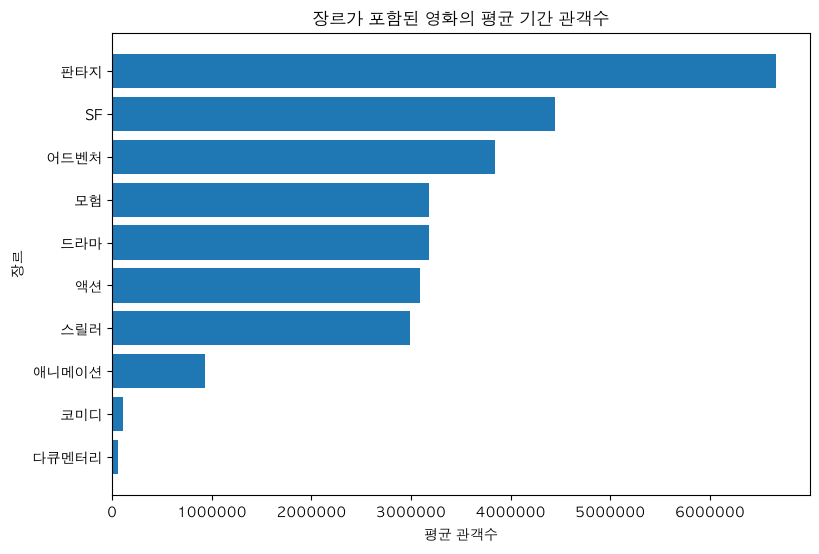

In [49]:
# 장르별 평균 기간 관객수 시각화
genre_plot = (
    genre_summary
    .sort_values("avg_audience", ascending=True)
)

plt.figure(figsize=(9, 6))
plt.barh(
    genre_plot.index,
    genre_plot["avg_audience"]
)
plt.title("장르가 포함된 영화의 평균 기간 관객수")
plt.xlabel("평균 관객수")
plt.ylabel("장르")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

### 4-2-2. 관람 등급과 국가에 따른 비교

In [50]:
# 관람등급 / 국가별 영화 수와 평균 관객수
grade_summary = (
    top12_df
    .groupby("grade")
    .agg(
        movie_count=("movieNm", "nunique"),
        avg_audience=("audiAcc", "mean")
    )
    .sort_values("avg_audience", ascending=False)
)

country_summary = (
    top12_df
    .groupby("nation")
    .agg(
        movie_count=("movieNm", "nunique"),
        avg_audience=("audiAcc", "mean")
    )
    .sort_values("avg_audience", ascending=False)
)

print("[관람등급]")
display(grade_summary)

print("[국가]")
display(country_summary)


[관람등급]


,movie_count,avg_audience
grade,,
15세이상관람가,4,2318818.75
12세이상관람가,3,2289026.00
전체관람가,5,1108504.00


[국가]


,movie_count,avg_audience
nation,,
미국,6,2.479129e+06
한국,4,1.652378e+06
일본,2,1.002945e+05


#### A. 15세 이상 관람가와 미국 영화가 가장 관객수가 높다.

- 영화의 등급 중에선 전체 관람가 영화가 가장 많지만 흥행에 항상 유리한 것은 아니라고 해석할 수 있다.
- 미국 영화가 전체 관람객 수의 약 50%를 차지하며 인기가 높다.

### 4-2-3. 러닝타임에 따른 비교

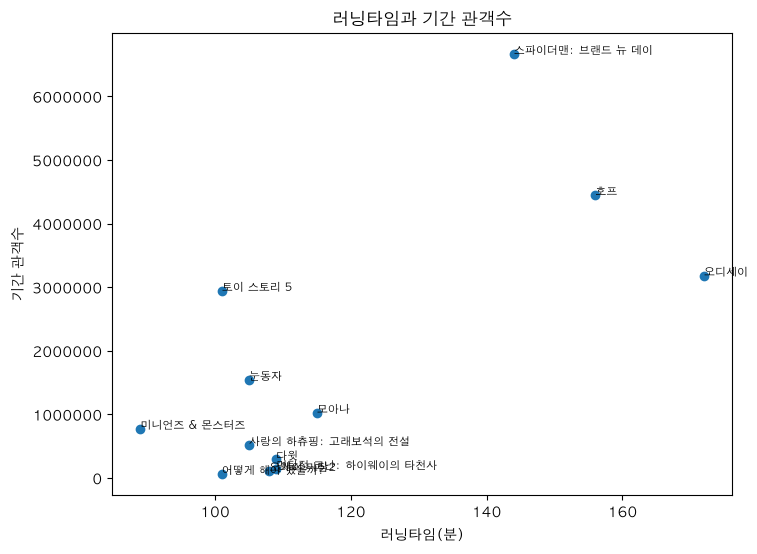

In [51]:
# 러닝타임과 기간 관객수
plt.figure(figsize=(8, 6))
plt.scatter(
    top12_df["time"],
    top12_df["audiAcc"]
)

for _, row in top12_df.iterrows():
    plt.annotate(
        row["movieNm"],
        (row["time"], row["audiAcc"]),
        fontsize=8
    )

plt.title("러닝타임과 기간 관객수")
plt.xlabel("러닝타임(분)")
plt.ylabel("기간 관객수")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

#### A. 러닝타임과 관객수 간의 유효한 상관성은 발견되지 않음

- 러닝 타임이 긴 영화('오디세이', '스파이더맨: 브랜드 뉴 데이', '호프')가 기간 관객수 상위권을 차지하는 경향을 보였으나, 전체적으로 특정 러닝 타임 길수록 관객 수가 증가한다고 단정하기는 어렵다.

### 4-2-4. 개봉 후 경과일에 따른 비교

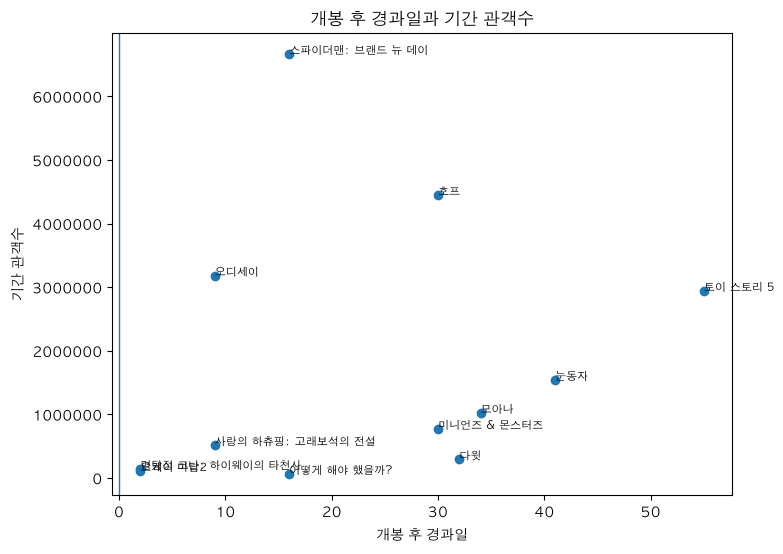

In [52]:
# 개봉 후 경과일과 기간 관객수
plt.figure(figsize=(8, 6))
plt.scatter(
    top12_df["days_since_release"],
    top12_df["audiAcc"]
)

for _, row in top12_df.iterrows():
    plt.annotate(
        row["movieNm"],
        (row["days_since_release"], row["audiAcc"]),
        fontsize=8
    )

plt.axvline(0, linewidth=1)
plt.title("개봉 후 경과일과 기간 관객수")
plt.xlabel("개봉 후 경과일")
plt.ylabel("기간 관객수")
plt.ticklabel_format(style="plain", axis="y")
plt.show()


#### A. 흥행 상위권 영화들은 개봉 후 비교적 짧은 기간(10~30일 이내)에 높은 관객수를 기록하는 경향이 있음

### 4-2-5. 평론가 평점과 관객 수의 관계

In [53]:
# 영화별 평론가 점수 요약
expert_score_summary = (
    top12_df
    .groupby(["expert_score", "movieNm"])
    .agg(
        avg_audiAcc=("audiAcc", "mean")
    )
    .reset_index()
)

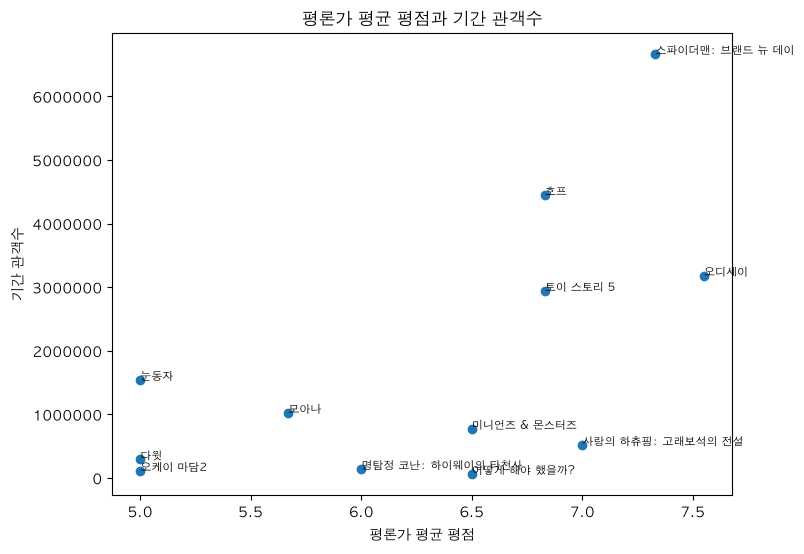

In [54]:
plt.figure(figsize=(8, 6))
plt.scatter(
    expert_score_summary["expert_score"],
    expert_score_summary["avg_audiAcc"]
)

for _, row in expert_score_summary.iterrows():
    plt.annotate(
        row["movieNm"],
        (row["expert_score"], row["avg_audiAcc"]),
        fontsize=8
    )

plt.title("평론가 평균 평점과 기간 관객수")
plt.xlabel("평론가 평균 평점")
plt.ylabel("기간 관객수")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

#### A. 전문가 평점은 대부분의 영화에서 6~8점 사이

-  '스파이더맨: 브랜드 뉴 데이'와 '오디세이'는 높은 평점을 기록하며 높은 관객수를 유지중임

> 즉, 평점이 높은 영화는 무조건 흥행한다라고 볼 수는 없으나, 흥행 영화의 성공 요인 중 높은 평점인 것도 사실 중요하다고 볼 수 있음

### 4-2-5. 관객 평점과 관객 수의 관계

In [55]:
# 코난은 관객 평점이 아직 없어서 삭제 진행
top12_df_drop_0 = top12_df[top12_df['audi_score'] != 0].copy()

In [56]:
# 영화별 평론가 점수 요약
audi_score_summary = (
    top12_df_drop_0
    .groupby(["audi_score", "movieNm"])
    .agg(
        avg_audiAcc=("audiAcc", "mean")
    )
    .reset_index()
)

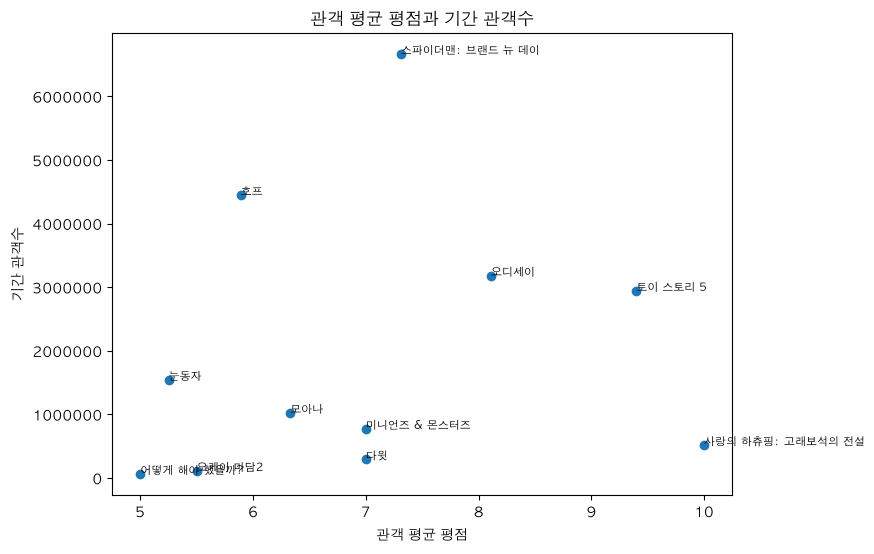

In [57]:
plt.figure(figsize=(8, 6))
plt.scatter(
    audi_score_summary["audi_score"],
    audi_score_summary["avg_audiAcc"]
)

for _, row in audi_score_summary.iterrows():
    plt.annotate(
        row["movieNm"],
        (row["audi_score"], row["avg_audiAcc"]),
        fontsize=8
    )

plt.title("관객 평균 평점과 기간 관객수")
plt.xlabel("관객 평균 평점")
plt.ylabel("기간 관객수")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

#### A. 관객 평점은 일반적으로 5 ~ 8점 사이

-  관객 평점이 높을수록 관객 수가 높은 패턴이 아주 약하게 보이긴 하나, 평점이 흥행에 절대적인 요소라고 보기에는 어렵다.
- 전문가와 달리 관심이 아예 없는 영화는 관람조차 하지 않아서 발생하는 현상일 가능성이 높다.
- 사랑의 하츄핑과 토이스토리는 타깃 대상에게는 매우 높은 만족도를 기록한 영화일 가능성이 높다.

### 4-2-6. 관객 평점과 전문가 평점의 관계

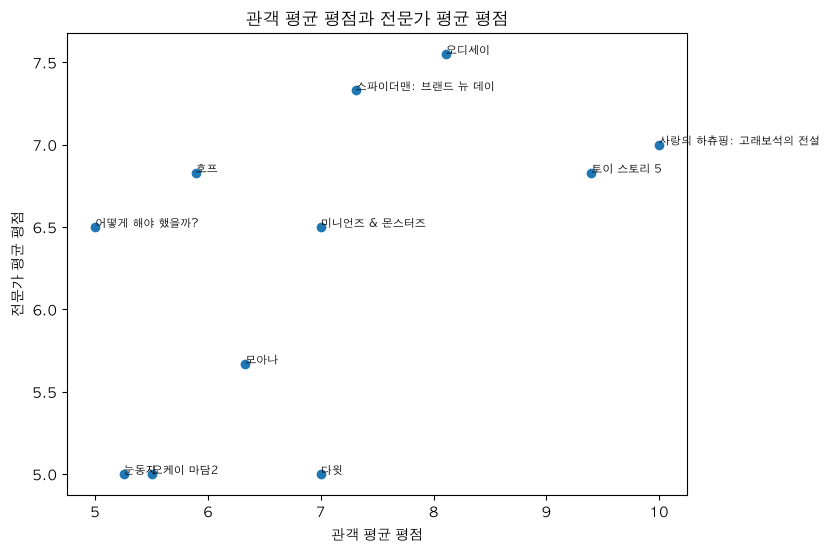

In [58]:
plt.figure(figsize=(8, 6))
plt.scatter(
    top12_df_drop_0["audi_score"],
    top12_df_drop_0["expert_score"]
)

for _, row in top12_df_drop_0.iterrows():
    plt.annotate(
        row["movieNm"],
        (row["audi_score"], row["expert_score"]),
        fontsize=8
    )

plt.title("관객 평균 평점과 전문가 평균 평점")
plt.xlabel("관객 평균 평점")
plt.ylabel("전문가 평균 평점")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

#### A. 관객 시선과 전문가의 평점 

- 보통 관객의 평점과 전문가의 평점이 양의 상관관계를 보이는 경향이 있다.
- 하츄핑과 토이스토리와 같은 영화는 전문가에 판단에 비해 타깃층을 생각 이상으로 만족시켰을 가능성이 크다.

# 5. 시계열 분석

## 5-1. Kobis 데이터 확인
시계열 분석은 Kobis API를 통해 확보한 1년치 데이터 활용.

In [59]:
movie_df.shape

(3650, 19)

In [60]:
movie_df.head(2)

,rank,rankInten,rankOldAndNew,movieCd,movieNm,openDt,salesAmt,salesShare,salesInten,salesChange,salesAcc,audiCnt,audiInten,audiChange,audiAcc,scrnCnt,showCnt,b_date,c_date
0,1,0,OLD,20241941,좀비딸,2025-07-30,2835148970,41.6,1802045840,174.4,38201765980,290709,179756,162.0,4046131,1438,6343,2025-08-15,2026-08-15 16:20:45
1,2,0,OLD,20254501,F1 더 무비,2025-06-25,1598074170,23.4,966333630,153.0,42788953890,140886,84004,147.7,3971606,937,2792,2025-08-15,2026-08-15 16:20:45


In [61]:
daily = (
    movie_df
    .groupby("b_date", as_index=False)
    .agg(
        total_audience=("audiCnt", "sum"),   # 해당 날짜의 전체 관객수 합계
        total_sales=("salesAmt", "sum"),        # 해당 날짜의 전체 매출액 합계
        total_screens=("scrnCnt", "sum"),      # 해당 날짜의 전체 스크린 수 합계
        total_shows=("showCnt", "sum"),          # 해당 날짜의 전체 상영 횟수 합계
        movie_count=("movieCd", "nunique")         # 해당 날짜에 집계된 고유 영화 수
    )
    .sort_values("b_date")
    .reset_index(drop=True)
)

daily.head()

,b_date,total_audience,total_sales,total_screens,total_shows,movie_count
0,2025-08-15,618277,6323513030,5998,16280,10
1,2025-08-16,553060,5763850790,5956,16013,10
2,2025-08-17,455365,4676093740,5880,14960,10
3,2025-08-18,142234,1400825000,4907,12793,10
4,2025-08-19,132869,1298717150,4884,12566,10


In [62]:
daily.shape

(365, 6)

In [63]:
# 만든 daily에서 빠진 날짜는 없는지 확인하는 코드

full_dates = pd.date_range(
    start=daily["b_date"].min(),
    end=daily["b_date"].max(),
    freq="D"
)

missing_dates = full_dates.difference(
    daily["b_date"]
)

print("누락 날짜 수:", len(missing_dates))

누락 날짜 수: 0


## 5-2. EDA 및 전처리
💡 일별 관객수 분포 확인

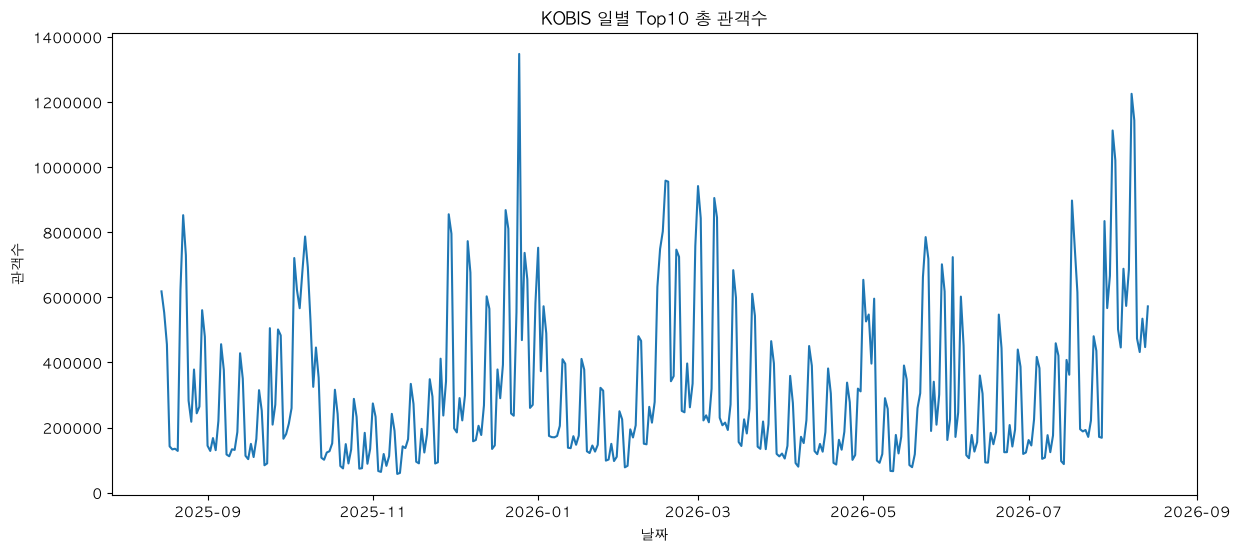

In [64]:
# 일별 관객수 시각화
plt.figure(figsize=(14, 6))

plt.plot(
    daily["b_date"],
    daily["total_audience"]
)

plt.title("KOBIS 일별 Top10 총 관객수")
plt.xlabel("날짜")
plt.ylabel("관객수")
plt.ticklabel_format(style="plain", axis="y")

plt.show()

#### A. 관객수 분포는 짧은 주기를 반복해 크게 뛰는 패턴

**1. 주기적인 급등과 하락의 반복**
- 관객수 분포가 상승 또는 하락하는 짧은 주기의 업다운을 하는 구조
    - 주말에 관객수가 상승하는 패턴을 보여주는 것은 아닐까? => 주간 계절성!
        - 2025년 추석 연휴는 대체 공휴일과 한글날이 겹쳐 1주일이 휴무였음

**2. 특정 날짜의 이상치성 피크**
- 2025년 말 부근, 약 140만 명 수준의 매우 큰 피크
    - 한 영화때문인지, 연말 특수인지 해석해볼 필요가 있음
- 2026년 7월 이후 역시 피크
    - 관객 규모가 확실히 커졌다는 건 확인되나 전체적 흐름이라고 판단하기는 아직 이름
    - 특히 2026년 8월 9일까지만의 데이터이므로, 여름 성수기 효과인지 장기 상승 추세인지를 파악하기는 아직 이른 단계임

**3. 장기적으로 일정한 증가·감소 추세가 뚜렷하지 않음**
- 낮은 구간과 높은 구간의 반복
    - 따라서 단순한 직선형 추세보다는 **계절성과 이벤트 효과가 더 강한 시계열**

### 2025년 연말 중 관객 수가 가장 많았던 날짜 찾기

In [65]:
# 2025년 11~12월 데이터 추출
end_2025 = daily[
    (daily["b_date"] >= "2025-11-01")
    & (daily["b_date"] <= "2025-12-31")
]

# 일별 관객수가 가장 많았던 날짜 Top10
peak_dates = (
    end_2025
    .sort_values("total_audience", ascending=False)
    .head(10)
)

peak_dates[["b_date", "total_audience"]]

,b_date,total_audience
132,2025-12-25,1347645
127,2025-12-20,867966
106,2025-11-29,855168
128,2025-12-21,810493
107,2025-11-30,795389
113,2025-12-06,772542
134,2025-12-27,736560
114,2025-12-07,676226
135,2025-12-28,655452
120,2025-12-13,603016


=> 크리스마스에 관객이 많았음
- 공휴일 및 연말의 특수성으로 해석할 수 있음

In [66]:
# 가장 관객수가 많았던 날짜의 영화 확인
peak_date = peak_dates.iloc[0]["b_date"]

peak_movies = (
    movie_df[movie_df["b_date"] == peak_date]
    .sort_values("audiCnt", ascending=False)
)

peak_movies[["rank", "movieNm", "audiCnt", "audiAcc"]]

,rank,movieNm,audiCnt,audiAcc
1320,1,아바타: 불과 재,640291,2982886
1321,2,주토피아 2,431302,7030038
1322,3,"오늘 밤, 세계에서 이 사랑이 사라진다 해도",115268,182063
1323,4,극장판 짱구는 못말려: 초화려! 작열하는 떡잎마을 댄서즈,113600,163297
1324,5,뽀로로 극장판 스위트캐슬 대모험,28011,176262
1325,6,윗집 사람들,6276,531277
1326,7,프레디의 피자가게 2,4467,224914
1327,8,만약에 우리,3255,15673
1328,9,위키드: 포 굿,2616,957054
1329,10,척의 일생,2559,7686


구글링 결과, 

**아바타: 불과 재는 개봉 15일 만에 500만 관객을 동원함**

- 관련 기사: https://www.chosun.com/entertainments/movie/2026/01/02/HBQWMYRZMNRGKZTEMU2WEMZWMY/
- 대작의 속편이라는 강점
    - 팬들의 기대가 큼
- 빠르게 관객 동원

**주토피아 2는 국내 개봉 800만 관객을 넘김**
- 관련 기사: https://www.munhwa.com/article/11556798
- 할리우드 애니메이션 역대 최고 흥행 1위 영화
    - 겨울왕국2와 인사이드 아웃2의 기록을 넘음
- 역대 국내 개봉 애니메이션 흥행 순위 최상위권 (Top4)

> 💁 결국, 당시 2025년 최대 흥행작 두 편이 상영시기가 겹치면서 연말 특수 현상을 나타낸 것으로 해석.

#### 💡7일 이동 평균 확인

일별 데이터는 출렁임이 클 수 밖에 없으므로 장기 흐름을 확인할 겸 7일 이동평균을 확인

In [67]:
# 7일 이동 평균 파생변수 생성
daily["audience_ma7"] = (
    daily["total_audience"]
    .rolling(7)
    .mean()
)

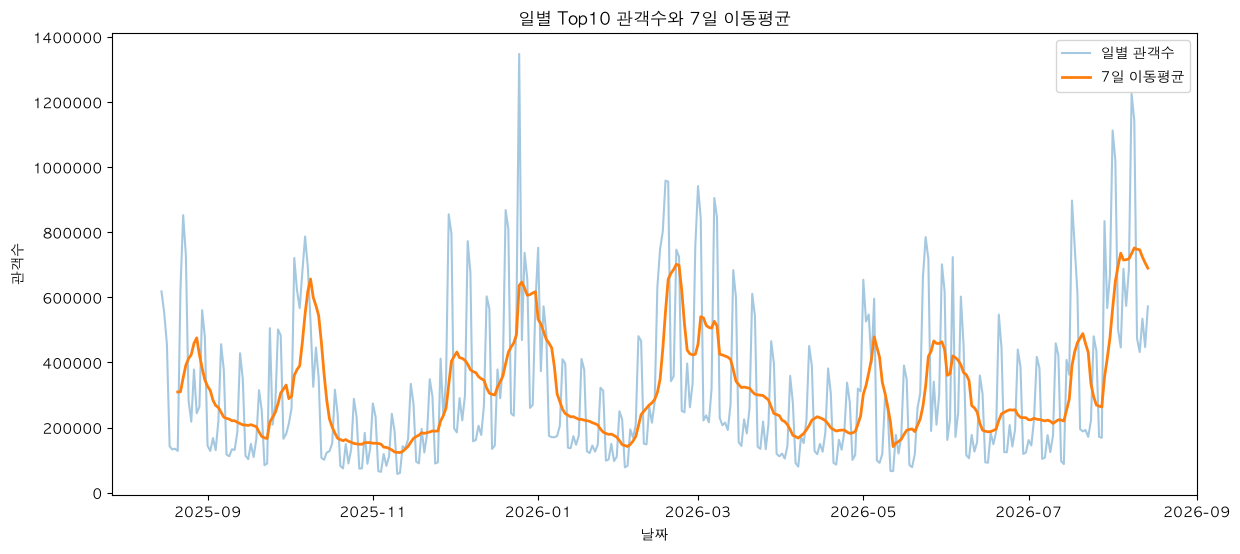

In [68]:
# 시각화
plt.figure(figsize=(14, 6))

plt.plot(
    daily["b_date"],
    daily["total_audience"],
    alpha=0.4,
    label="일별 관객수"
)

plt.plot(
    daily["b_date"],
    daily["audience_ma7"],
    linewidth=2,
    label="7일 이동평균"
)

plt.title("일별 Top10 관객수와 7일 이동평균")
plt.xlabel("날짜")
plt.ylabel("관객수")
plt.legend()
plt.ticklabel_format(style="plain", axis="y")

plt.show()

**7일 이동평균을 적용하면 일별 관객수의 급격한 변동이 완화되고, 흥행 흐름이 더 뚜렷하게 보임**

- 일별 관객수는 주말이나 특정 흥행일에 급격히 상승함
    - 하루 단위 그래프에서는 값의 등락이 너무 커 전체적인 흐름을 파악하기 어려움
- 7일 이동평균은 최근 7일의 관객수를 평균내어 표시
    - 평일과 주말의 차이를 일부 완화
    - 단기적인 급등락보다는 관객수의 전반적인 상승/하락 흐름을 확인하기 쉬움

**그래프에서는 일정한 주기로 흥행 상승 구간과 하락 구간이 반복됨**
- 2025년 9~10월 사이 한 차례 관객수 상승
    - 약 7일간 이어진 추석 황금 연휴로 인한 가능성
- 2025년 12월에는 이동평균 자체가 크게 상승
    - 앞서 확인한 연말 흥행작들의 영향이 단순 하루의 급등이 아니라 며칠 이상 지속된 흥행 흐름으로 나타남
- 2026년 2~3월에도 다시 높은 수준의 관객수 흐름이 나타남
    - 구정 연휴과 개강 전 특수 기간 + `왕과 사는 남자`라는 역대 국내 영화 2위의 흥행기록인 영화 개봉 기간
- 2026년 5월 전후에도 단기적인 상승 구간이 확인됨

**2026년 7~8월에는 이전보다 강한 상승 흐름이 나타남**
- 7월 말부터 이동평균선이 빠르게 상승
- 8월에는 7일 평균 관객수 자체가 70만 명 이상 수준까지 올라감
- 특정 하루만 관객수가 많았던 것이 아니라 여러 날에 걸쳐 높은 관객수가 유지되고 있음을 의미

> 💁 일별 관객수에서는 주말·특정 날짜의 급등이 먼저 보이지만, 7일 이동평균으로 보면 영화시장의 흥행이 **'짧은 피크'가 아니라 일정 기간 지속되는 상승과 하락의 흐름**으로 나타난다는 점을 확인할 수 있습니다.

>📌 단, 여기서의 관객수는 전체 영화 관객수가 아니라 **KOBIS 일별 Top10 영화의 관객수 합계**이므로, 전체 영화시장 규모의 변화라기보다 ‘상위 흥행작들의 관객 흐름’으로 해석

### 요일 변수 생성
위 분석을 통해 주기성이 있다는 것을 확인했으므로, 요일에 대한 파생변수 생성

In [69]:
daily["weekday"] = daily["b_date"].dt.dayofweek

weekday_names = {
    0: "월",
    1: "화",
    2: "수",
    3: "목",
    4: "금",
    5: "토",
    6: "일"
}

# 요일 정보
daily["weekday_name"] = (daily["weekday"].map(weekday_names))

# 주말인가 아닌가
daily["is_weekend"] = (daily["weekday"] >= 5)

#### 💡 요일별 평균/중앙값 관객수

In [70]:
weekday_summary = (
    daily
    .groupby(["weekday", "weekday_name"])
    .agg(
        avg_audience=("total_audience", "mean"),
        median_audience=("total_audience", "median")
    )
    .reset_index()
    .sort_values("weekday")
)

weekday_summary

,weekday,weekday_name,avg_audience,median_audience
0,0,월,200676.519231,131015.5
1,1,화,183131.576923,126267.0
2,2,수,288439.576923,195227.5
3,3,목,233731.480769,170313.0
4,4,금,298111.377358,224895.0
5,5,토,540715.711538,480524.5
6,6,일,490175.230769,439835.0


=> 주말의 관객수가 평균/중앙값 모두 높음

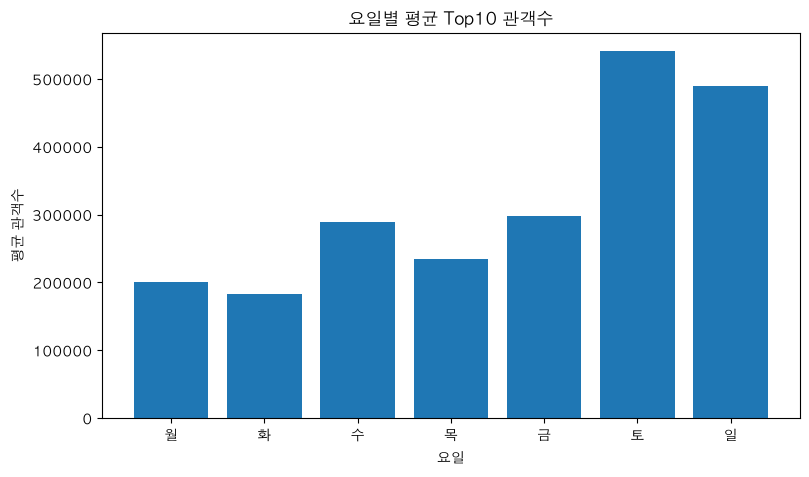

In [71]:
# 시각화

plt.figure(figsize=(9, 5))

plt.bar(
    weekday_summary["weekday_name"],
    weekday_summary["avg_audience"]
)

plt.title("요일별 평균 Top10 관객수")
plt.xlabel("요일")
plt.ylabel("평균 관객수")
plt.ticklabel_format(style="plain", axis="y")

plt.show()

### 주말 / 평일 비교

In [72]:
# 주말과 평일의 관람객 수 확인
weekend_summary = (
    daily
    .groupby("is_weekend")
    .agg(
        avg_audience=("total_audience", "mean"),
        median_audience=("total_audience", "median")
    )
)

weekend_summary

,avg_audience,median_audience
is_weekend,,
False,241037.620690,171925.0
True,515445.471154,457412.5


In [73]:
# 주말과 평일의 관람객 수 비율 차이 확인

weekday_mean = daily.loc[
    daily["is_weekend"] == False,
    "total_audience"
].mean()

weekend_mean = daily.loc[
    daily["is_weekend"] == True,
    "total_audience"
].mean()

weekend_ratio = weekend_mean / weekday_mean

print(f"{weekend_ratio:.2f}배")

2.14배


주말과 평일의 관객 수는 2배가 차이나지만,<br>
주말은 2일 / 평일은 5일동안 집계된 상태에서 발생한 현상이므로,<br>
실제 주말과 평일의 파워 차이는 약 10배 정도로 생각할 수 있다.

## 5-3. 시계열 분석 진행

### 5-3-1. 시계열 분석용 데이터 변환
날짜를 index 지정하고, 총 관람객 수를 넣은 단변량 시계열 분석 진행

In [74]:
ts = (
    daily
    .set_index("b_date")["total_audience"]
    .asfreq("D")
)

ts.head()

b_date
2025-08-15    618277
2025-08-16    553060
2025-08-17    455365
2025-08-18    142234
2025-08-19    132869
Freq: D, Name: total_audience, dtype: int64

In [75]:
# 결측치 확인
# 시계열 데이터는 간혹 날짜별로 조합 또는 수정하다가 결측치가 발생하는데, 그 때 모델에 넣을 수 없기 때문에 꼭 확인 필요

ts.isna().sum()

np.int64(0)

### 5-3-2. STL 분해

In [76]:
period=7                       # 일주일의 계절성이 확실하므로 기간은 7일!

stl = STL(ts, period=7, robust=True)

stl_result = stl.fit()

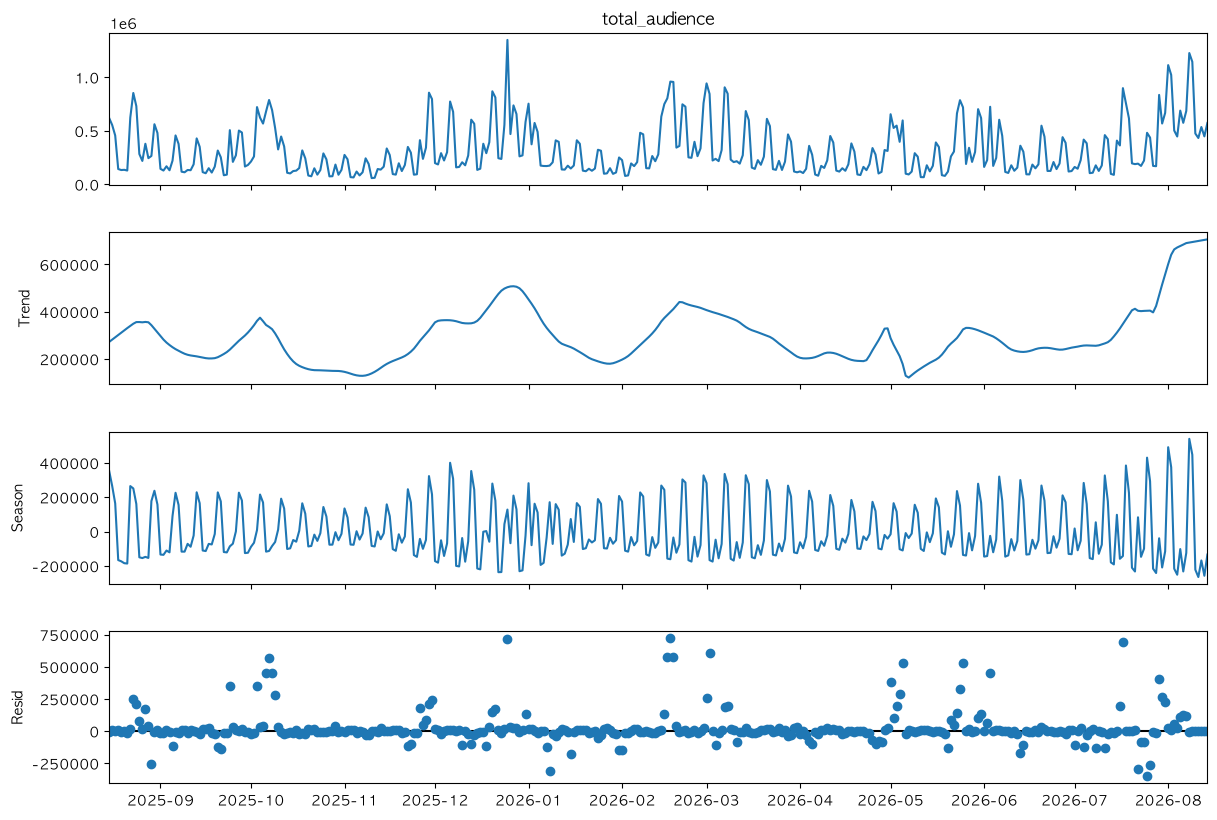

In [77]:
fig = stl_result.plot()
fig.set_size_inches(14, 9)

plt.show()

#### **결과 해석**

**STL 분해 결과, 관객수에는 추세와 반복적인 계절성이 함께 존재함**

- **Trend**
    - 2025년 하반기에는 전반적으로 관객수 수준이 낮아지는 구간이 나타남
    - 2025년 연말과 2026년 2~3월에 다시 상승
    - 2026년 7~8월에는 추세 자체가 빠르게 상승함

- **Season**
    - 일정한 간격으로 상승과 하락이 반복됨
    - 영화관 관객수에 **주간 단위의 계절성**이 존재할 가능성이 높음

- **Residual**
    - 대부분은 0 근처에 분포하지만 특정 시점에 큰 잔차가 발생
- 대작 개봉, 공휴일, 연휴처럼 일반적인 추세와 계절성만으로 설명하기 어려운 이벤트의 영향일 가능성이 있음

> 💁 결국, 영화 관객수는 단순히 랜덤하게 변하는 것이 아니라 **장기적인 흥행 흐름 + 반복되는 주간 패턴 + 특정 이벤트 효과** 가 함께 섞여 있는 시계열이라고 볼 수 있다.

### 5-3-3. ADF 정상성 검정

In [78]:
adf_result = adfuller(
    ts.dropna()
)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -3.7207511642014115
p-value: 0.0038305596308375184


=> 정상성을 가진 시계열

#### 1차 차분

In [79]:
ts_diff = (ts.diff().dropna())

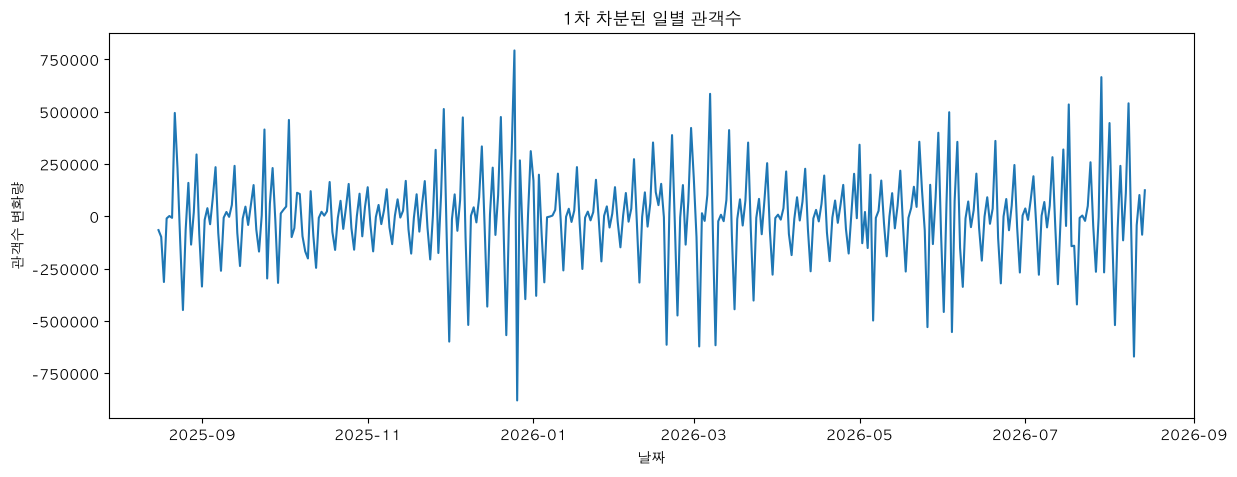

In [80]:
plt.figure(figsize=(14, 5))

plt.plot(ts_diff)

plt.title("1차 차분된 일별 관객수")
plt.xlabel("날짜")
plt.ylabel("관객수 변화량")

plt.show()

1차 차분후 다시 ADF

In [81]:
adf_diff_result = adfuller(
    ts_diff
)

print("ADF Statistic:", adf_diff_result[0])
print("p-value:", adf_diff_result[1])

ADF Statistic: -5.903360167673481
p-value: 2.744775141287596e-07


=> 1차 차분 후 역시 정상 시계열!

### 5-3-4. ACF 자기상관성 확인

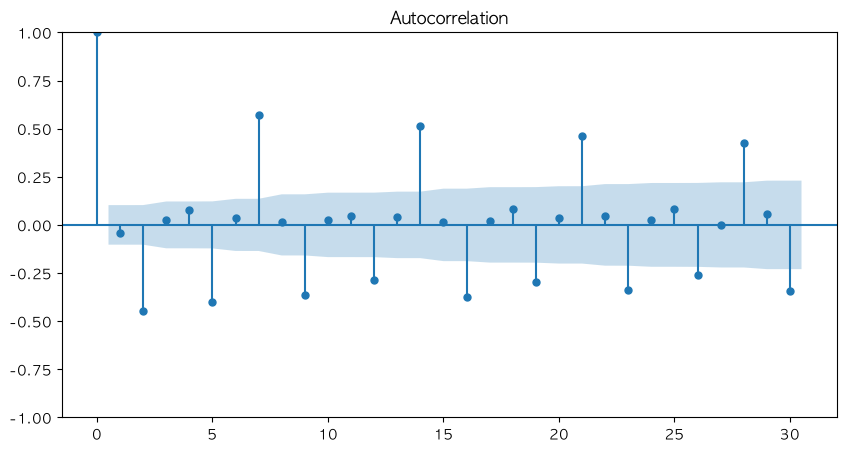

In [82]:
fig = plot_acf(
    ts_diff,
    lags=30
)

fig.set_size_inches(10, 5)
plt.show()

* 7일 간격으로 비슷한 관객수 패턴이 반복되는 모습
* 앞서 확인한 주간 계절성과 연결되는 결과
> 영화 관객수는 하루 전보다 일주일 전의 패턴과 더 강하게 연결되는 경향

### 5-3-5. 데이터 준비

Train / Test 분리
- 시계열 데이터이므로 시간순으로 분리
- 마지막 28일을 테스트로 지정

In [83]:
test_size = 28

train = ts.iloc[:-test_size]
test = ts.iloc[-test_size:]

### 5-3-6. Seasonal Naive 기준 모델

In [84]:
seasonal_naive = pd.Series(
    np.resize(
        train.iloc[-7:].values,                     # Train의 마지막 7일만 반복
        len(test)
    ),
    index=test.index
)

### 5-3-7. ARIMA

In [85]:
arima_model = ARIMA(
    train,
    order=(1, 1, 1)
)

arima_result = arima_model.fit()

In [86]:
# 예측

arima_pred = arima_result.forecast(
    steps=len(test)
)

arima_pred.index = test.index

### 5-3-8. SARIMA

In [87]:
sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7)                         # 7일 주기
)

sarima_result = sarima_model.fit(
    disp=False
)

In [88]:
# 예측

sarima_pred = sarima_result.forecast(
    steps=len(test)
)

sarima_pred.index = test.index

### 5-3-9. 성능 평가

In [89]:
# 성능 평가 함수 정의
def evaluate_model(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.abs((actual - predicted) / actual).mean() * 100
    return mae, rmse, mape

In [90]:
# 모델 성능 비교

naive_mae, naive_rmse, naive_mape = evaluate_model(test, seasonal_naive)
arima_mae, arima_rmse, arima_mape = evaluate_model(test, arima_pred)
sarima_mae, sarima_rmse, sarima_mape = evaluate_model(test, sarima_pred)

In [91]:
# 모델별 결과 깔끔하게 보기 위해 df
model_result = pd.DataFrame({
    "model": ["Seasonal Naive", "ARIMA", "SARIMA"],
    "MAE": [naive_mae, arima_mae, sarima_mae],
    "RMSE": [naive_rmse, arima_rmse, sarima_rmse],
    "MAPE": [naive_mape, arima_mape, sarima_mape]
})

model_result.sort_values("MAE")

,model,MAE,RMSE,MAPE
2,SARIMA,280125.064780,317431.469949,55.591105
0,Seasonal Naive,296161.500000,364579.111459,60.556215
1,ARIMA,300013.714898,383091.982326,54.909039


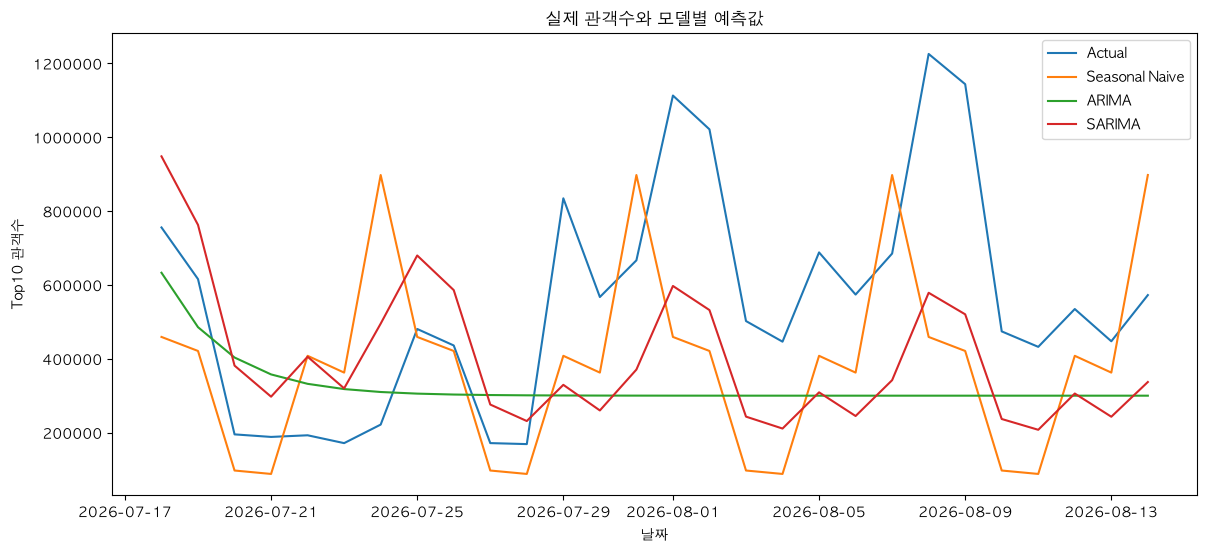

In [92]:
# 예측값 시각화
plt.figure(figsize=(14, 6))

plt.plot(test, label="Actual")
plt.plot(seasonal_naive, label="Seasonal Naive")
plt.plot(arima_pred, label="ARIMA")
plt.plot(sarima_pred, label="SARIMA")

plt.title("실제 관객수와 모델별 예측값")
plt.xlabel("날짜")
plt.ylabel("Top10 관객수")
plt.legend()
plt.ticklabel_format(style="plain", axis="y")

plt.show()

#### **모델별 예측 결과 비교**

- **Seasonal Naive와 SARIMA**는 7일 주기의 반복 패턴은 비교적 잘 따라감
- 하지만 실제 관객수가 크게 증가하는 시점에서는 **예측값이 실제값보다 크게 낮게 나타남**
- 특히나, ARIMA는 기준 모델보다도 MAE가 높음
    - 즉, 모델 자체를 잘못 파악했다는 것!

# 6. 2차 시계열 모델링

In [93]:
# ADF 한꺼번에 확인

adf_check = {
    "원본": train,
    "1차 차분": train.diff(),
    "7일 계절 차분": train.diff(7),
    "1차 + 7일 계절 차분": train.diff().diff(7)
}

for name, series in adf_check.items():
    result = adfuller(series.dropna())
    print(f"{name}: p-value = {result[1]:.4f}")

원본: p-value = 0.0005
1차 차분: p-value = 0.0000
7일 계절 차분: p-value = 0.0000
1차 + 7일 계절 차분: p-value = 0.0000


=> 이미 원본 p-value가 0에 가까우므로 굳이 d=1이 필요하지 않음

#### **<참조 - PACF>**

ACF가 총 연관성이라면, PACF는 알짜배기(순수) 연관성

- ACF 그래프: 시차 lag별 자기상관을 보여주는 시각화 그래프
    - 예) "월요일이 추웠더니 수요일도 춥네? 둘이 연관이 깊구나!"
- PACF 그래프: 다른 시차들의 간접 효과를 통제한 **순수 자기상관관계**
    - 예) "잠깐, 화요일이 추워서 수요일이 추워진 거 싹 빼고! 월요일이 수요일에 '직접' 미친 힘만 남기면 얼마나 되지?" (화요일의 간접 효과를 싹 제거하고 1:1로만 측정)

---
즉, ACF와 PACF를 비교하면, 중간을 빼고 특정 시차와의 직접 관계가 있는지를 해석 할 수 있음. 이 과정을 통해 `p` 판단에 도움이 됨!

<참조>
- ACF: 현재 값과 과거 값의 상관이 몇 시차까지 이어지는지 봄 → MA 계열 q, 계절성 주기 탐색에 도움
- PACF: 중간 시차의 영향을 제거하고 특정 시차와의 직접 관계를 봄 → AR 계열 p 판단에 도움

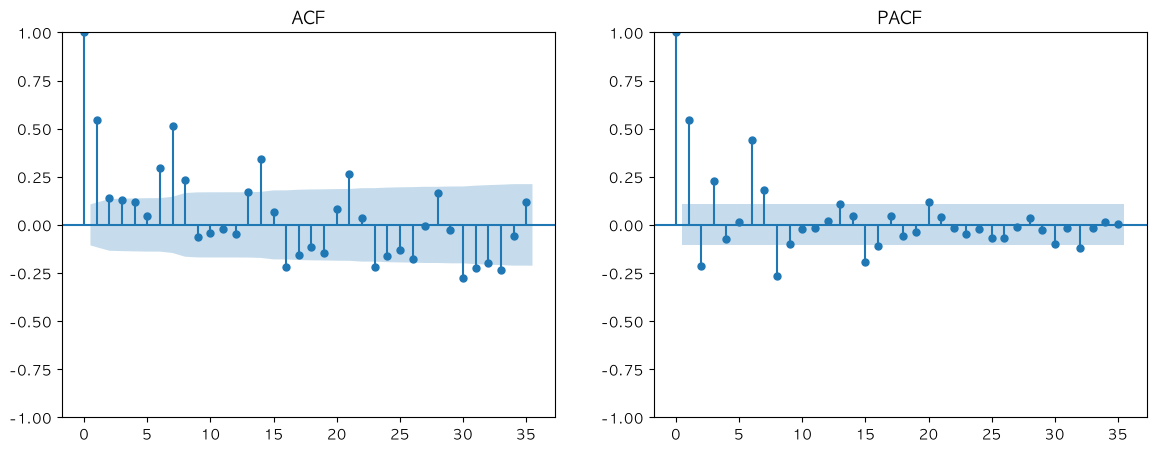

In [94]:
# ACF와 PACF 확인
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(train.dropna(), lags=35, ax=ax[0])
plot_pacf(train.dropna(), lags=35, ax=ax[1])

ax[0].set_title("ACF")
ax[1].set_title("PACF")

plt.show()

#### ACF / PACF 그래프 해석
- x축 = 얼마나 과거와 비교했는가 (lag)
- y축 = 그 과거와 현재가 얼마나 비슷하게 움직이는가 (자기상관계수)

**1. ACF**
- `lag 1`에서 비교적 강한 양의 자기상관
- 특히 `lag 7`, `14`, `21` 부근에서 반복적으로 자기상관이 높게 나타남
- ACF가 `lag 1`에서 바로 끊기는 형태는 아니므로, `q`는 하나의 값으로 확정하기보다 여러 후보를 비교해야 함

**2. PACF**
- `lag 1`에서 가장 뚜렷한 양의 값
- 따라서 `p`는 우선 **1을 첫 번째 후보**로 고려

#### 🪞 Seasonal Naive 기준 모델 2차

In [95]:
seasonal_naive_2 = pd.Series(
    np.resize(
        train.iloc[-7:].values,                     # Train의 마지막 7일만 반복
        len(test)
    ),
    index=test.index
)

#### ⚙️ARIMA 2차

In [96]:
# (1, 1, 0)로 지정
arima_model_2 = ARIMA(
    train,
    order=(1, 1, 0)
)

arima_result_2 = arima_model_2.fit()

In [97]:
# 예측

arima_pred_2 = arima_result_2.forecast(
    steps=len(test)
)

arima_pred_2.index = test.index

#### 🔄 SARIMA 2차

In [98]:
# (1,1,0)(1,0,0,7)로 지정

sarima_model_2 = SARIMAX(
    train,
    order=(1, 1, 0),
    seasonal_order=(1, 0, 0, 7)
)

sarima_result_2 = sarima_model_2.fit(
    disp=False
)

In [99]:
# 예측

sarima_pred_2 = sarima_result_2.forecast(
    steps=len(test)
)

sarima_pred_2.index = test.index

#### 📊 2차 모델 성능 평가

In [100]:
# 2차 모델 성능 비교

naive2_mae, naive2_rmse, naive2_mape = evaluate_model(test, seasonal_naive_2)
arima2_mae, arima2_rmse, arima2_mape = evaluate_model(test, arima_pred_2)
sarima2_mae, sarima2_rmse, sarima2_mape = evaluate_model(test, sarima_pred_2)

In [101]:
# 모델별 결과 깔끔하게 보기 위해 df
model_result_2 = pd.DataFrame({
    "model": ["Seasonal Naive", "ARIMA", "SARIMA"],
    "MAE": [naive2_mae, arima2_mae, sarima2_mae],
    "RMSE": [naive2_rmse, arima2_rmse, sarima2_rmse],
    "MAPE": [naive2_mape, arima2_mape, sarima2_mape]
})

model_result_2.sort_values("MAE")

,model,MAE,RMSE,MAPE
0,Seasonal Naive,296161.500000,364579.111459,60.556215
1,ARIMA,392345.173675,438875.570847,132.189382
2,SARIMA,802477.492524,846457.761271,219.214489


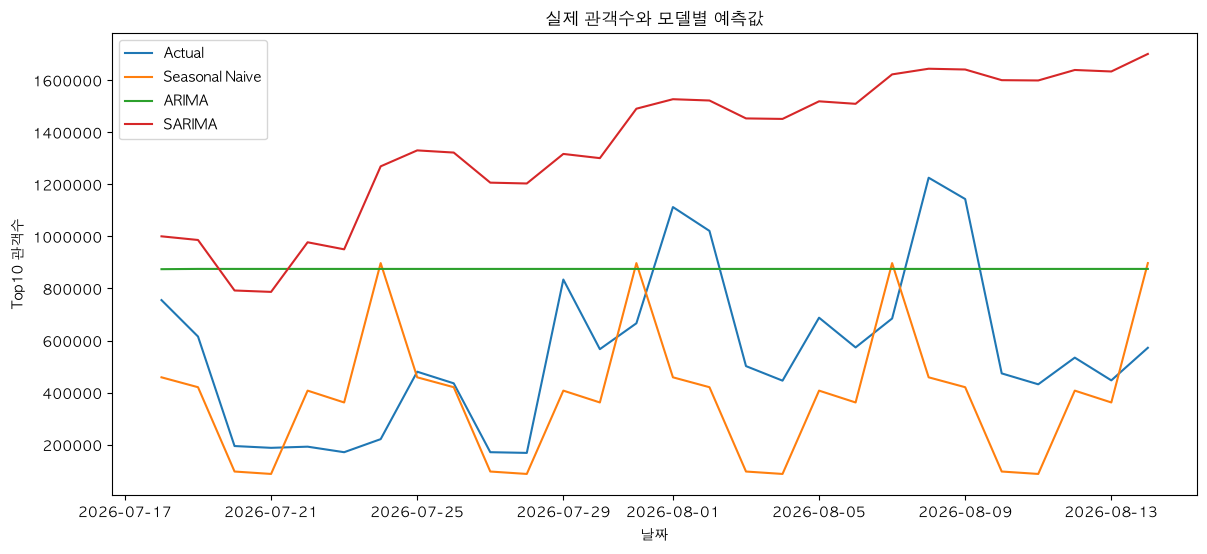

In [102]:
# 예측값 시각화
plt.figure(figsize=(14, 6))

plt.plot(test, label="Actual")
plt.plot(seasonal_naive_2, label="Seasonal Naive")
plt.plot(arima_pred_2, label="ARIMA")
plt.plot(sarima_pred_2, label="SARIMA")

plt.title("실제 관객수와 모델별 예측값")
plt.xlabel("날짜")
plt.ylabel("Top10 관객수")
plt.legend()
plt.ticklabel_format(style="plain", axis="y")

plt.show()

# 7. 3차 시계열 모델링

정상성이 이미 확보된 원본 데이터에 대해 `d=0`으로 수정하여 과대차분을 방지하고 정상적인 예측을 수행합니다.

#### ⚙️ARIMA 3차

In [103]:
# (1, 0, 0)로 지정
arima_model_3 = ARIMA(
    train,
    order=(1, 0, 0)
)

arima_result_3 = arima_model_3.fit()

In [104]:
# 예측

arima_pred_3 = arima_result_3.forecast(
    steps=len(test)
)

arima_pred_3.index = test.index

#### 🔄 SARIMA 3차

In [105]:
# (1,0,0)(1,0,0,7)로 지정

sarima_model_3 = SARIMAX(
    train,
    order=(1, 0, 0),
    seasonal_order=(1, 0, 0, 7)
)

sarima_result_3 = sarima_model_3.fit(
    disp=False
)

In [106]:
# 예측

sarima_pred_3 = sarima_result_3.forecast(
    steps=len(test)
)

sarima_pred_3.index = test.index

#### 📊 3차 모델 성능 평가

In [107]:
# 3차 모델 성능 비교

naive3_mae, naive3_rmse, naive3_mape = evaluate_model(test, seasonal_naive_2) # 기준 모델은 2차와 동일
arima3_mae, arima3_rmse, arima3_mape = evaluate_model(test, arima_pred_3)
sarima3_mae, sarima3_rmse, sarima3_mape = evaluate_model(test, sarima_pred_3)

In [108]:
# 모델별 결과 깔끔하게 보기 위해 df
model_result_3 = pd.DataFrame({
    "model": ["Seasonal Naive", "ARIMA", "SARIMA"],
    "MAE": [naive3_mae, arima3_mae, sarima3_mae],
    "RMSE": [naive3_rmse, arima3_rmse, sarima3_rmse],
    "MAPE": [naive3_mape, arima3_mape, sarima3_mape]
})

model_result_3.sort_values("MAE")

,model,MAE,RMSE,MAPE
0,Seasonal Naive,296161.500000,364579.111459,60.556215
1,ARIMA,300032.239438,383116.016333,54.889591
2,SARIMA,346259.195742,427797.831237,63.841013


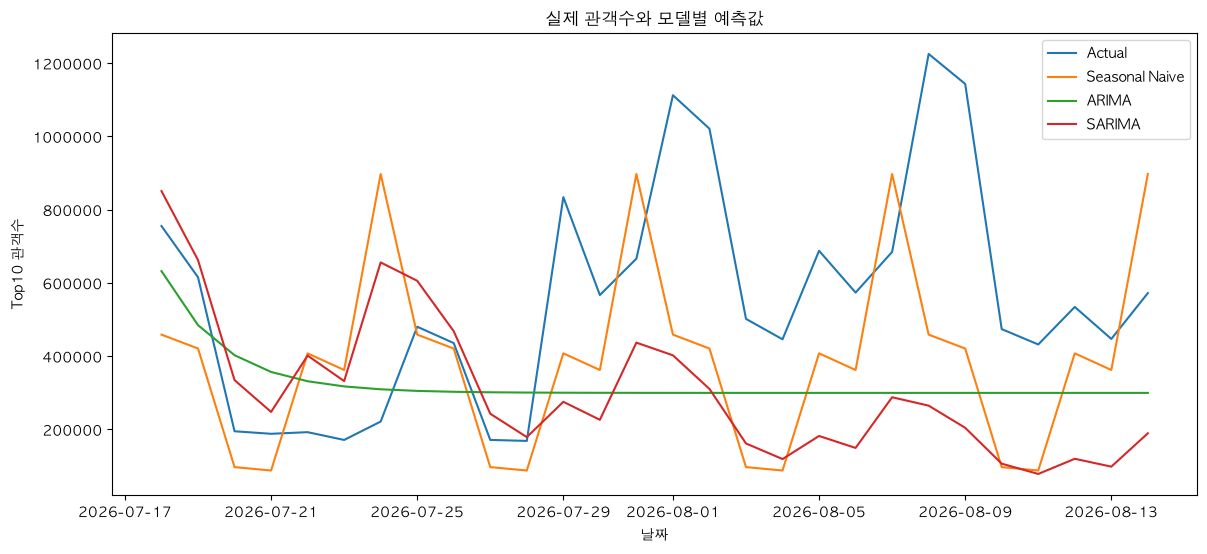

In [109]:
# # 시각화
# plt.figure(figsize=(12, 6))
# plt.plot(train.index[-30:], train.iloc[-30:], label='Train (last 30 days)')
# plt.plot(test.index, test, label='Actual Test')
# plt.plot(test.index, seasonal_naive_2, label='Seasonal Naive', linestyle='--')
# plt.plot(test.index, arima_pred_3, label='ARIMA (1,0,0)', linestyle='-.')
# plt.plot(test.index, sarima_pred_3, label='SARIMA (1,0,0)(1,0,0,7)', linestyle=':')

# plt.title("3차 시계열 모델 예측 결과 비교")
# plt.legend()
# plt.show()

# 예측값 시각화
plt.figure(figsize=(14, 6))

plt.plot(test, label="Actual")
plt.plot(seasonal_naive_2, label="Seasonal Naive")
plt.plot(arima_pred_3, label="ARIMA")
plt.plot(sarima_pred_3, label="SARIMA")

plt.title("실제 관객수와 모델별 예측값")
plt.xlabel("날짜")
plt.ylabel("Top10 관객수")
plt.legend()
plt.ticklabel_format(style="plain", axis="y")

plt.show()

# 8. 4차 시계열 모델링 (로그 변환 + Auto-ARIMA)

영화 관객수 데이터의 큰 편차와 우하향하는 지수적 감소 추세를 안정화하기 위해 **로그 변환(Log Transformation)**을 수행하고, `pmdarima`의 `auto_arima`를 사용하여 AIC 기준 최적의 파라미터를 탐색합니다.

In [110]:
%pip install pmdarima

Note: you may need to restart the kernel to use updated packages.


In [111]:
import pmdarima as pm
import numpy as np

# 1. 로그 변환 (log1p는 log(1+x)로, 0인 값에서도 에러가 나지 않게 해줍니다)
train_log = np.log1p(train)
test_log = np.log1p(test)

# 2. Auto-ARIMA를 사용한 최적 파라미터 자동 탐색
# 일별 데이터이므로 주간 계절성(m=7)을 반영합니다.
auto_model = pm.auto_arima(
    train_log,
    seasonal=True,
    m=7,  # 주간 계절성
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    max_p=3, max_q=3,
    max_P=2, max_Q=2,
    trace=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=440.361, Time=0.40 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=709.468, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=inf, Time=0.21 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=459.293, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=2654.652, Time=0.00 sec
 ARIMA(2,0,2)(0,0,1)[7] intercept   : AIC=449.772, Time=0.29 sec
 ARIMA(2,0,2)(1,0,0)[7] intercept   : AIC=inf, Time=0.36 sec
 ARIMA(2,0,2)(2,0,1)[7] intercept   : AIC=inf, Time=0.58 sec
 ARIMA(2,0,2)(1,0,2)[7] intercept   : AIC=438.773, Time=0.71 sec
 ARIMA(2,0,2)(0,0,2)[7] intercept   : AIC=416.271, Time=0.61 sec
 ARIMA(1,0,2)(0,0,2)[7] intercept   : AIC=414.801, Time=0.61 sec
 ARIMA(1,0,2)(0,0,1)[7] intercept   : AIC=448.485, Time=0.09 sec
 ARIMA(1,0,2)(1,0,2)[7] intercept   : AIC=inf, Time=0.71 sec
 ARIMA(1,0,2)(1,0,1)[7] intercept   : AIC=446.367, Time=0.36 sec
 ARIMA(0,0,2)(0,0,2)[7] intercept   : AIC=413.338, Time=0.12 s

In [112]:
# 3. 예측 (결과값이 로그 스케일로 나옴)
pred_log = auto_model.predict(n_periods=len(test))

# 4. 원래 스케일로 복구 (지수 변환: expm1)
pred_4 = np.expm1(pred_log)
pred_4.index = test.index

#### 📊 4차 모델 성능 평가

In [113]:
# 4차 모델 성능 평가
auto_mae, auto_rmse, auto_mape = evaluate_model(test, pred_4)

# 3차 모델 결과와 비교
model_result_4 = pd.DataFrame({
    "model": ["Seasonal Naive", "ARIMA (3차)", "SARIMA (3차)", "Auto-ARIMA + Log (4차)"],
    "MAE": [naive3_mae, arima3_mae, sarima3_mae, auto_mae],
    "RMSE": [naive3_rmse, arima3_rmse, sarima3_rmse, auto_rmse],
    "MAPE": [naive3_mape, arima3_mape, sarima3_mape, auto_mape]
})

model_result_4.sort_values("MAE")

,model,MAE,RMSE,MAPE
3,Auto-ARIMA + Log (4차),296019.608249,371110.091736,46.667737
0,Seasonal Naive,296161.500000,364579.111459,60.556215
1,ARIMA (3차),300032.239438,383116.016333,54.889591
2,SARIMA (3차),346259.195742,427797.831237,63.841013


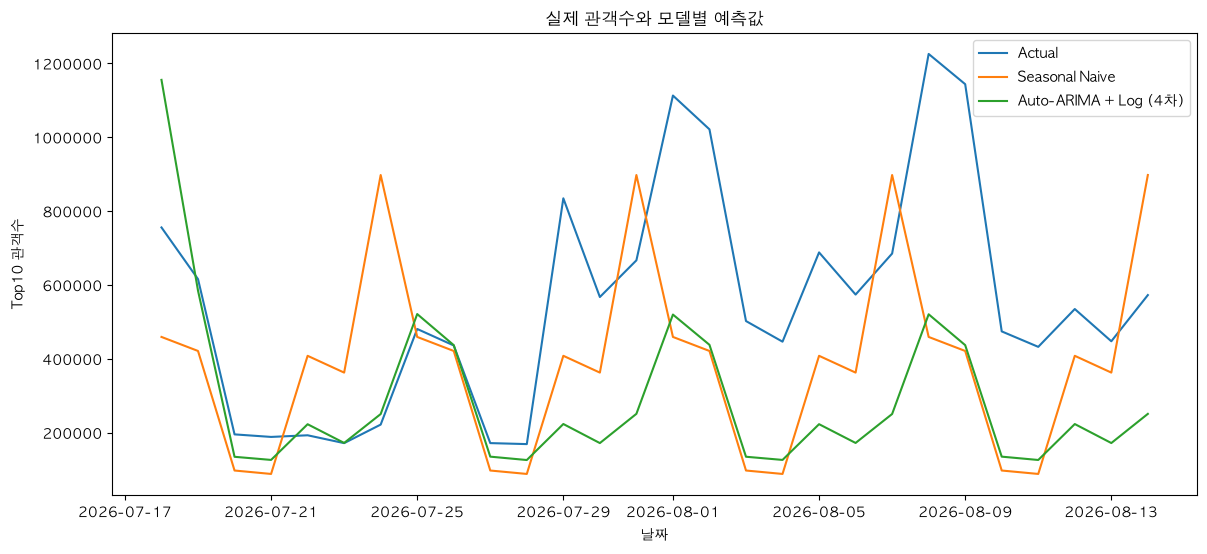

In [114]:
# 예측값 시각화
plt.figure(figsize=(14, 6))

plt.plot(test, label="Actual")
plt.plot(seasonal_naive_2, label="Seasonal Naive")
plt.plot(pred_4, label="Auto-ARIMA + Log (4차)")

plt.title("실제 관객수와 모델별 예측값")
plt.xlabel("날짜")
plt.ylabel("Top10 관객수")
plt.legend()
plt.ticklabel_format(style="plain", axis="y")

plt.show()

# 9. 리뷰 텍스트 분석 (KoNLPy 활용)

`kiwipiepie` 설치 에러(Mac 환경 호환성 문제 등)를 피하기 위해, 더 범용적인 `KoNLPy`의 `Okt` 형태소 분석기를 사용하여 명사를 추출합니다.

In [115]:
# konlpy 설치
%pip install konlpy

Note: you may need to restart the kernel to use updated packages.


In [116]:
import os
os.environ['JAVA_HOME'] = '/opt/homebrew/opt/openjdk'

from konlpy.tag import Okt
from collections import Counter
import plotly.express as px

# Okt 형태소 분석기 초기화
okt = Okt()

# 1. 리뷰 데이터 텍스트 전처리 및 명사 추출 함수 정의
def extract_nouns_okt(text):
    if not isinstance(text, str):
        return []
    
    # 명사 추출
    nouns = okt.nouns(text)
    
    # 한 글자 명사 제외
    nouns = [noun for noun in nouns if len(noun) > 1]
    
    return nouns

# 2. 모든 리뷰 텍스트에서 명사 추출
all_nouns = []
for review_text in review_df['review']:
    all_nouns.extend(extract_nouns_okt(review_text))

# 3. 빈도수 계산
noun_counts = Counter(all_nouns)

# 가장 자주 등장한 상위 15개 키워드 확인
top_keywords = noun_counts.most_common(15)

# 데이터프레임으로 변환
keyword_df = pd.DataFrame(top_keywords, columns=['keyword', 'count'])
keyword_df

,keyword,count
0,놀런,4
1,영화,4
2,히어로,2
3,영웅,2
4,세상,2
5,역시,2
6,스파이더맨,2
7,고통,2
8,캐릭터,2
9,가장,2


In [117]:
# 4. 키워드 빈도수 시각화 (Plotly)
fig = px.bar(
    keyword_df, 
    x='keyword', 
    y='count', 
    text='count',
    title='Top 10 영화 리뷰 핵심 키워드 빈도수 (KoNLPy 분석)',
    labels={'keyword': '키워드', 'count': '빈도수'},
    color='count',
    color_continuous_scale='Blues'
)

fig.update_layout(
    xaxis_title='키워드',
    yaxis_title='빈도수',
    template='plotly_white',
    width=900,
    height=500
)

fig.show()

# 10. 워드클라우드 시각화 (전체 및 영화별)

KoNLPy를 통해 추출한 키워드(명사) 빈도수를 바탕으로 전체 영화 리뷰와 각 영화별 리뷰의 워드클라우드를 생성합니다.

In [118]:
# 워드클라우드 라이브러리 설치
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


findfont: Failed to find font weight bold, now using 400.


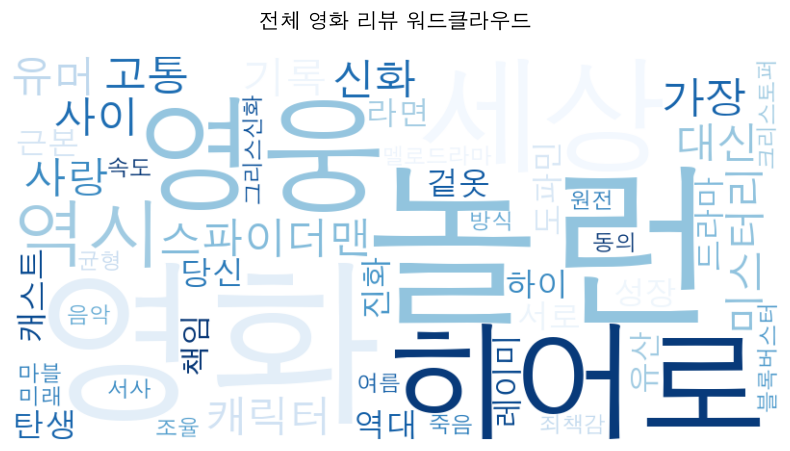

In [119]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 맥(Mac) 기본 한글 폰트 경로 (Windows의 경우 'malgun' 등으로 변경 필요)
font_path = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'

def generate_wordcloud(word_counts, title):
    wc = WordCloud(
        font_path=font_path,
        width=800,
        height=400,
        background_color='white',
        colormap='Blues',
        max_words=50
    )
    
    cloud = wc.generate_from_frequencies(word_counts)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(cloud, interpolation='bilinear')
    plt.title(title, fontsize=15, pad=20, fontweight='bold')
    plt.axis('off')
    plt.show()

# 1. 전체 영화 리뷰 워드클라우드
generate_wordcloud(dict(noun_counts.most_common(50)), "전체 영화 리뷰 워드클라우드")

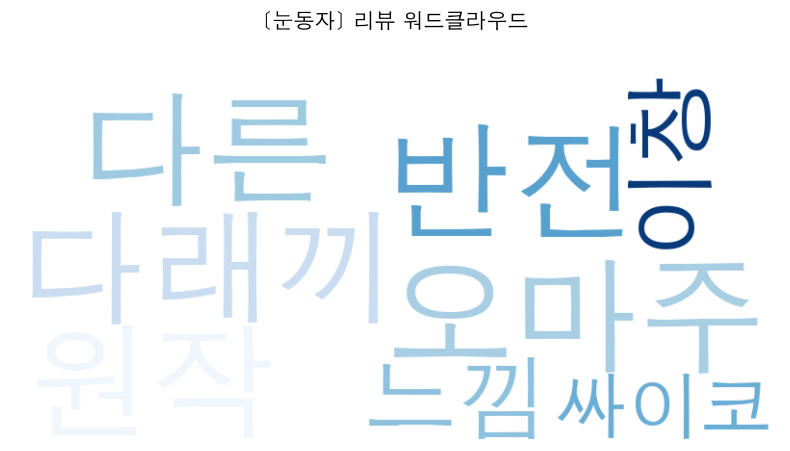

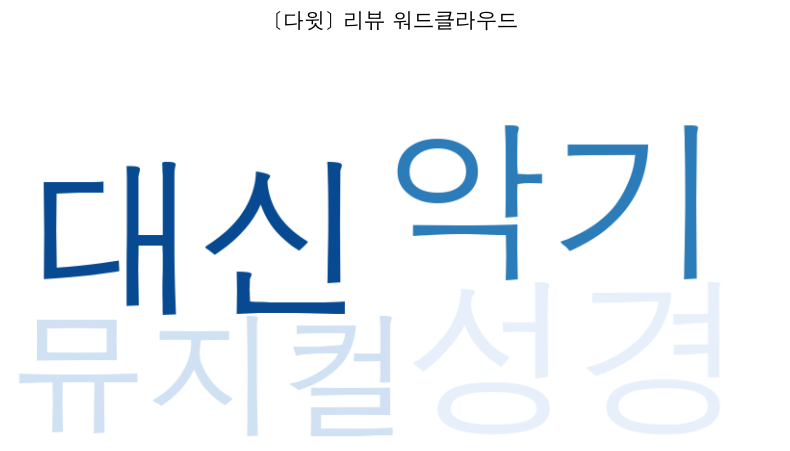

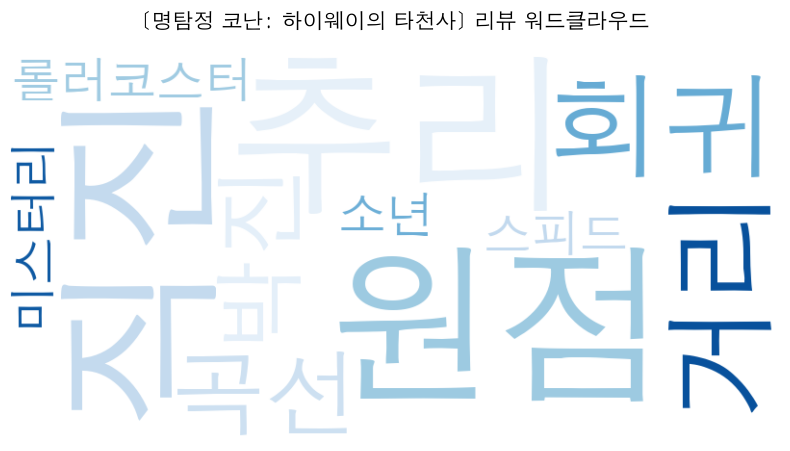

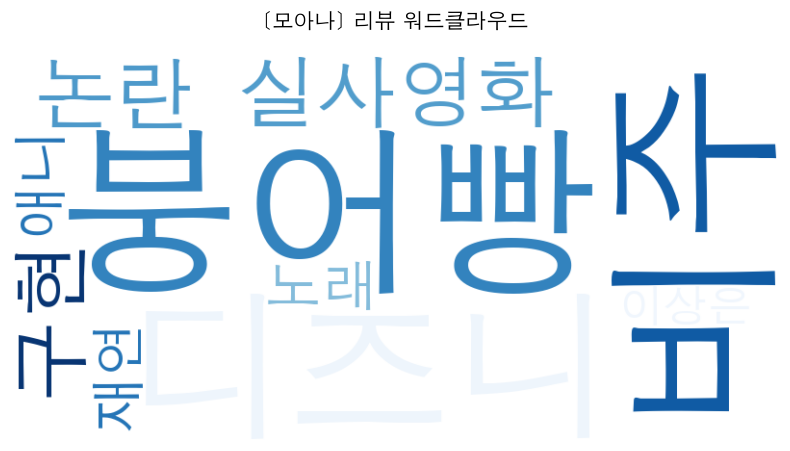

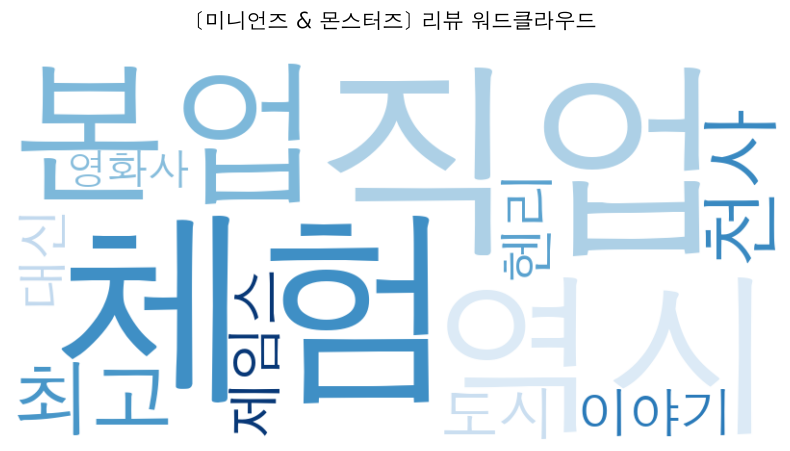

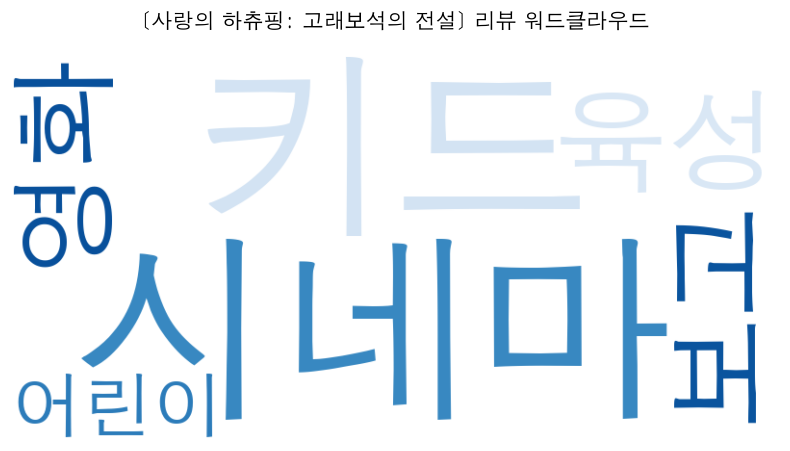

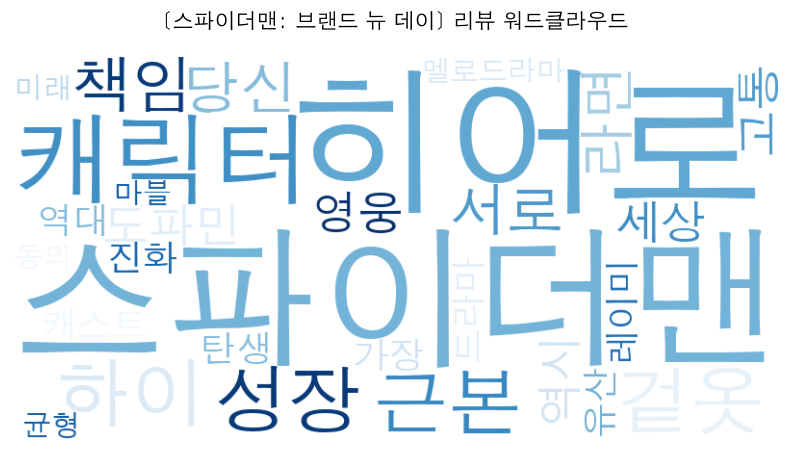

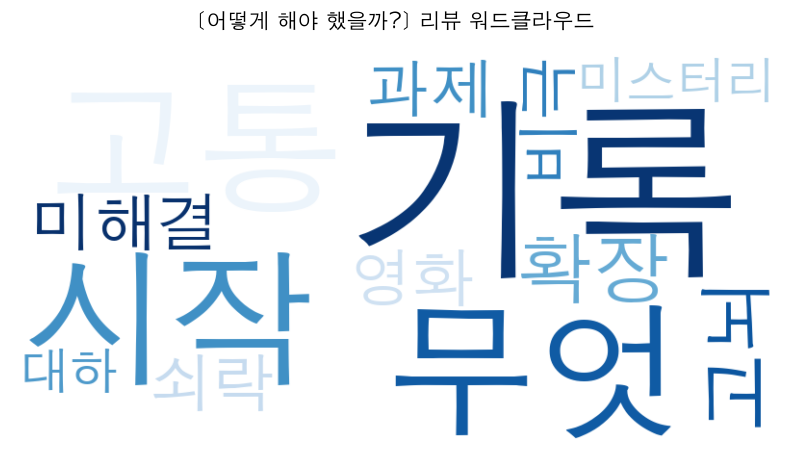

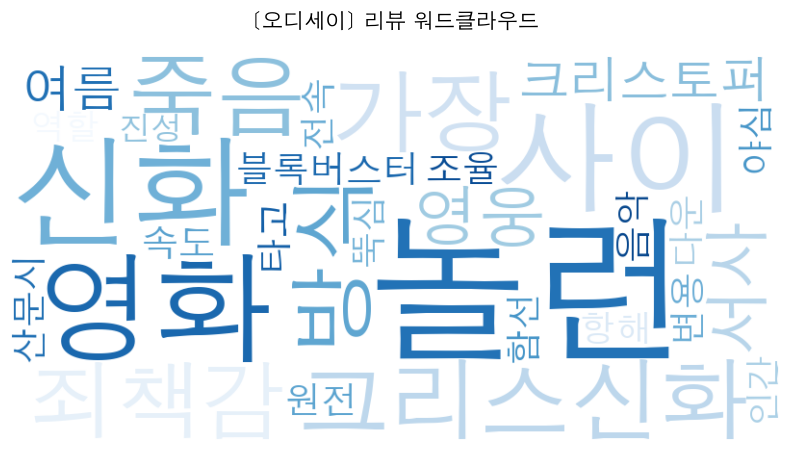

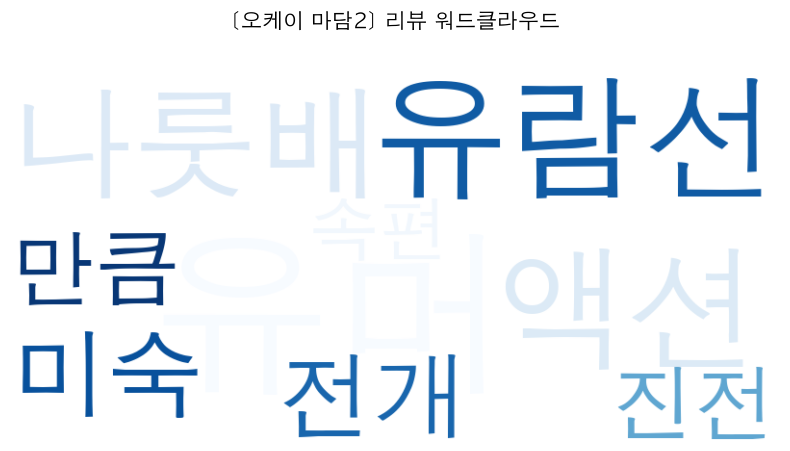

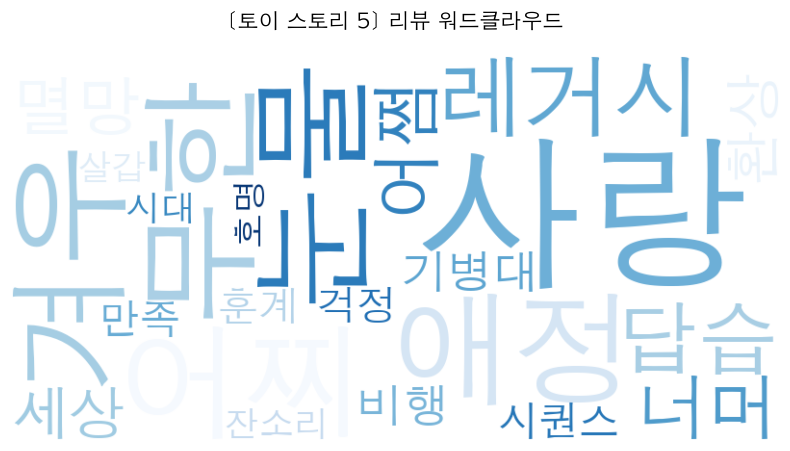

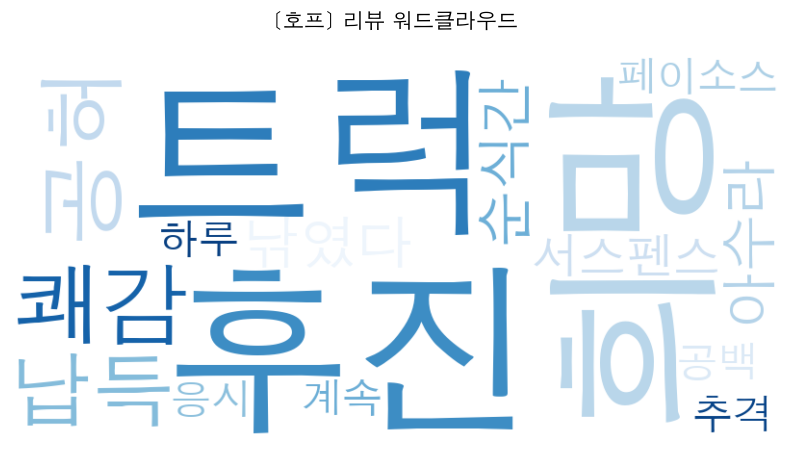

In [120]:
# 2. 영화별 워드클라우드를 그리기 위해 review 데이터에 영화 제목(title) 매핑
# merge(조인) 타입 에러를 방지하기 위해 id 컬럼의 데이터 타입을 float로 통일합니다.
review_df['id'] = pd.to_numeric(review_df['id'], errors='coerce')
master_df['id'] = pd.to_numeric(master_df['id'], errors='coerce')

review_with_title = review_df.merge(master_df[['id', 'title']], on='id', how='left')

# 영화별로 그룹화하여 워드클라우드 렌더링
for title, group in review_with_title.groupby('title'):
    movie_nouns = []
    for review_text in group['review']:
        movie_nouns.extend(extract_nouns_okt(review_text))
        
    movie_counts = Counter(movie_nouns)
    
    # 단어가 추출된 경우만 워드클라우드 생성
    if movie_counts:
        top_movie_words = dict(movie_counts.most_common(30))
        generate_wordcloud(top_movie_words, f"[{title}] 리뷰 워드클라우드")